# 🚍🚆🚊 Transit Equity in Montreal
## Do we serve everyone equally? A spatial analysis of STM, STL and RTL service *vs.* neighbourhood demographics.

**Author:** Bruna Bado  
**Last updated:** June 2026  
**Data sources:** STM, STL, RTL GTFS Static Feeds & Statistics Canada 2021 Census

---

## Abstract

Transit agencies are often evaluated on punctuality. But a harder and more important question is whether service runs *where it matters most*.

This analysis examines transit equity across the inner Montreal Census Metropolitan Area (CMA) by measuring the relationship between transit service levels and the socioeconomic characteristics of each neighbourhood.

First, we combine GTFS schedule data from 3 urban transit agencies: the STM (island of Montreal), STL (Laval) and RTL (Longueuil and inner South Shore). Then, we overlay it onto 2021 Census tract demographics. Together these agencies cover the densely populated urban core of the CMA with comparable, bus-oriented service networks, making inter-agency comparisons methodologically sound.

>**Scope note:**
>* exo's outer-suburb network (Couronnes Nord and Sud) and the REM are not included. exo's commuter rail operates a peak-hours model that is methodologically incompatible with headway-based urban service metrics. Additionally, its bus network spans 10+ separate GTFS feeds requiring significant additional harmonization.
>* A full-CMA analysis is a natural extension of this work.

**Research questions:**
1. Which Montreal CMA Census Tracts have the least transit service, measured by stop density and weekly trip frequency?
2. Are low-service areas correlated with lower median income, higher proportions of visible minorities, or higher rates of low income?
3. Which patterns emerge that could inform transit equity policy?

*All data used in this analysis is publicly available.*

---

## 1. Setup

In [119]:
# Standard library ──────────────────────────────────────────────────────────
import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Network ────────────────────────────────────────────────────────────────────
import requests

# Data manipulation ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# Geospatial ─────────────────────────────────────────────────────────────────
import geopandas as gpd
from shapely.geometry import Point

# Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from folium.plugins import HeatMap
from branca.colormap import linear

# Statistics ─────────────────────────────────────────────────────────────────
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Display settings ───────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='whitegrid', palette='muted')

# File paths (relative to the notebooks/ directory) ─────────────────────────
DATA_RAW       = os.path.join('..', 'data', 'raw')
DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIGURES        = os.path.join('..', 'figures')

for path in [DATA_RAW, DATA_PROCESSED, FIGURES,
             os.path.join(DATA_RAW, 'gtfs_stm'),
             os.path.join(DATA_RAW, 'gtfs_stl'),   # ← new
             os.path.join(DATA_RAW, 'gtfs_rtl'),   # ← new
             os.path.join(DATA_RAW, 'census')]:
    os.makedirs(path, exist_ok=True)

print("✅ All libraries loaded successfully.")
print(f"   Working directory: {os.getcwd()}")

✅ All libraries loaded successfully.
   Working directory: c:\Users\bruna\Documents\Data Analysis\transit-equity-montreal\notebooks


---

## 2. Data Sources

This analysis relies on five publicly available datasets:

| # | Source | Description | Format | Geography |
|---|--------|-------------|--------|-----------|
| 1 | **STM GTFS** | Scheduled routes, stops, and trip frequencies (island of Montreal) | ZIP of CSVs | Stop-level |
| 2 | **STL GTFS** | Scheduled routes, stops, and trip frequencies (Laval) | ZIP of CSVs | Stop-level |
| 3 | **RTL GTFS** | Scheduled routes, stops, and trip frequencies (Longueuil and inner South Shore) | ZIP of CSVs | Stop-level |
| 4 | **StatsCan 2021 Census – Boundaries** | Geographic boundaries for Census Tracts in the Montreal CMA | Shapefile | Census Tract |
| 5 | **StatsCan 2021 Census – Profile** | Demographic, income, and socioeconomic indicators | CSV | Census Tract |

### Why these specific agencies?

The STM, STL and RTL collectively serve the inner urban core of the Montreal CMA with comparable, bus-oriented networks. All 3 publish open GTFS feeds and operate frequent, all-day service, making their headway and trip-frequency metrics directly comparable. Their combined service area covers the vast majority of the CMA's densely populated Census Tracts.

### What is GTFS?
GTFS (General Transit Feed Specification) is an open standard used worldwide by transit agencies to publish scheduled timetables. A GTFS feed is a ZIP archive of inter-related CSV tables: routes, trips, stops, stop times, and calendar data. It is the same format that apps like Transit use to show riders when the next bus arrives. This analysis uses the **static** GTFS feed (scheduled timetable) for each agency.

### What is a Census Tract?
Census Tracts (CTs) are small, stable geographic units designed by Statistics Canada to have populations of roughly 2,500-8,000 people. They are the finest-grained geography at which StatsCan publishes full demographic and income breakdowns, making them ideal for neighbourhood-level equity analysis.

>**Data currency note:**
>* The GTFS feeds represent current scheduled service as of June 2026.
>* Census data is from the 2021 long-form census, which remains the most granular and reliable public source for the socioeconomic indicators used here. Demographic shifts since 2021 may affect some findings.

---

## 3. Data Loading and Preprocessing

### 3.1 GTFS - STM, STL and RTL

We download and parse GTFS schedule feeds from all 3 agencies. Because each feed uses its own internal ID numbering (stop IDs, trip IDs, etc.), we prefix every ID with the agency code (`STM_`, `STL_`, `RTL_`) before merging. This prevents ID collisions while preserving the ability to filter by agency at any point in the analysis.

In [120]:
# Reusable download helper ───────────────────────────────────────────────────

     # It downloads a file from `url` to `dest_path`. It skips if the file already exists, so it's safe to re-run.

def download_file(url: str, dest_path: str, label: str = "") -> bool:

    if os.path.exists(dest_path):
        size_mb = os.path.getsize(dest_path) / 1_048_576
        print(f"✅ {label} already exists ({size_mb:.1f} MB)... Skipping file.")
        return True

    print(f"⬇️  Downloading {label} ...")
    try:
        r = requests.get(url, stream=True, timeout=120)
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(dest_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=65_536):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    print(f"\r   {downloaded / total * 100:5.1f}%  "
                          f"({downloaded/1_048_576:.1f} / {total/1_048_576:.1f} MB)",
                          end="")
        print(f"\n✅ Saved to: {dest_path}")
        return True
    except Exception as e:
        print(f"\n❌ Download failed: {e}")
        if os.path.exists(dest_path):
            os.remove(dest_path)   # remove partial download
        return False

In [121]:
# GTFS agency definitions ────────────────────────────────────────────────────

     # Each agency entry contains:
     #   url            : direct download link for the GTFS ZIP
     #   path           : where we save it locally
     #   open_data_page : fallback URL if auto-download fails

AGENCIES = {
    'STM': {
        'url' : 'https://www.stm.info/sites/default/files/gtfs/gtfs_stm.zip',
        'path': os.path.join(DATA_RAW, 'gtfs_stm', 'gtfs_stm.zip'),
        'open_data_page': 'https://www.stm.info/en/about/developers',
    },
    'STL': {
        'url' : None,   # direct download not available; manual only (see below)
        'path': os.path.join(DATA_RAW, 'gtfs_stl', 'gtfs_stl.zip'),
        'open_data_page': 'https://stlaval.ca/about-us/public-information/open-data',
    },
    'RTL': {
        'url' : 'https://www.rtl-longueuil.qc.ca/transit/latestfeed/RTL.zip',
        'path': os.path.join(DATA_RAW, 'gtfs_rtl', 'gtfs_rtl.zip'),
        'open_data_page': 'https://www.rtl-longueuil.qc.ca/en-CA/open-data/',
    },
}

# Download all 3 feeds ───────────────────────────────────────────────────

download_failures = []

for code, info in AGENCIES.items():
    print(f"\n{code} {'─'*56}")

    if info['url'] is None:
        # Manual-only agency (check if file is already present)
        if os.path.exists(info['path']):
            size_mb = os.path.getsize(info['path']) / 1_048_576
            print(f"✅ {code} GTFS feed already exists ({size_mb:.1f} MB)... Skipping file.")
        else:
            print(f"⚠️  {code}: manual download required.")
            print(f"    1. Go to: {info['open_data_page']}")
            print(f"    2. Download the GTFS static feed (.zip)")
            print(f"    3. Save it as: {info['path']}")
            download_failures.append(code)
    else:
        success = download_file(info['url'], info['path'], label=f"{code} GTFS feed")
        if not success:
            download_failures.append(code)

if download_failures:
    print(f"\n⛔ Fix the above before running the next cell.")
else:
    print(f"\n{'─'*60}")
    print("✅ All three GTFS feeds ready.")


STM ────────────────────────────────────────────────────────
✅ STM GTFS feed already exists (57.1 MB)... Skipping file.

STL ────────────────────────────────────────────────────────
✅ STL GTFS feed already exists (2.6 MB)... Skipping file.

RTL ────────────────────────────────────────────────────────
✅ RTL GTFS feed already exists (5.6 MB)... Skipping file.

────────────────────────────────────────────────────────────
✅ All three GTFS feeds ready.


In [122]:
# Multi-agency GTFS loader ───────────────────────────────────────────────────

     # This function loads GTFS tables from a single ZIP and:
     #   1. Tags every row with the agency code.
     #   2. Prefixes all IDs (stop_id, trip_id, route_id, service_id) with the agency code so merged tables have globally unique IDs.
     #   3. Adds default values for optional columns that not all feeds include (location_type, pickup_type), so concatenation doesn't produce NaNs.

def load_and_tag_gtfs(zip_path: str, agency_code: str) -> tuple:
    """
    Load and tag GTFS tables from zip_path for a given agency_code.
    Returns: (stops, routes, trips, stop_times, calendar)
    """
    pfx = agency_code + '_'

    # Verify the file is actually a ZIP before trying to open it
    if not zipfile.is_zipfile(zip_path):
        raise ValueError(
            f"{agency_code}: File at {zip_path} is not a valid ZIP.\n"
            f"It may have been downloaded incorrectly (e.g. an HTML error page).\n"
            f"Delete the file, download it manually, and re-run."
        )
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        available = set(z.namelist())

        stops_df   = pd.read_csv(z.open('stops.txt'))
        routes_df  = pd.read_csv(z.open('routes.txt'))
        trips_df   = pd.read_csv(z.open('trips.txt'))
        st_df      = pd.read_csv(z.open('stop_times.txt'),
                                  dtype={'arrival_time': str,
                                         'departure_time': str})

        # calendar.txt is required by GTFS spec but some feeds use only calendar_dates.txt (we can use whichever is available)
        if 'calendar.txt' in available:
            cal_df = pd.read_csv(z.open('calendar.txt'))
        else:
            raise FileNotFoundError(
                f"{agency_code}: calendar.txt not found. "
                f"Available files: {available}"
            )

    # Add agency identifier to all tables ───────────────────────────────────
    
    for df in [stops_df, routes_df, trips_df, st_df, cal_df]:
        df['agency'] = agency_code

    # Ensure optional columns exist with sensible defaults ──────────────────
    
    # location_type: 0 = boarding stop
    if 'location_type' not in stops_df.columns:
        stops_df['location_type'] = 0
    else:
        stops_df['location_type'] = stops_df['location_type'].fillna(0).astype(int)

    # pickup_type: 0 = regular pickup
    if 'pickup_type' not in st_df.columns:
        st_df['pickup_type'] = 0
    else:
        st_df['pickup_type'] = st_df['pickup_type'].fillna(0).astype(int)

    # Prefix all IDs with agency code ───────────────────────────────────────
    
    stops_df['stop_id']    = pfx + stops_df['stop_id'].astype(str)

    routes_df['route_id']  = pfx + routes_df['route_id'].astype(str)

    trips_df['trip_id']    = pfx + trips_df['trip_id'].astype(str)
    trips_df['route_id']   = pfx + trips_df['route_id'].astype(str)
    trips_df['service_id'] = pfx + trips_df['service_id'].astype(str)

    st_df['trip_id']       = pfx + st_df['trip_id'].astype(str)
    st_df['stop_id']       = pfx + st_df['stop_id'].astype(str)

    cal_df['service_id']   = pfx + cal_df['service_id'].astype(str)

    return stops_df, routes_df, trips_df, st_df, cal_df

# Load all 3 agencies ────────────────────────────────────────────────────

print("📂 Loading GTFS tables for all agencies...\n")

all_stops, all_routes, all_trips, all_stop_times, all_calendar = [], [], [], [], []

for code, info in AGENCIES.items():
    print(f"{code} {'─'*25}")
    s, r, t, st, cal = load_and_tag_gtfs(info['path'], code)
    all_stops.append(s)
    all_routes.append(r)
    all_trips.append(t)
    all_stop_times.append(st)
    all_calendar.append(cal)
    print(f"    stops      : {len(s):>9,}")
    print(f"    routes     : {len(r):>9,}")
    print(f"    trips      : {len(t):>9,}")
    print(f"    stop_times : {len(st):>9,}")
    print(f"    calendar   : {len(cal):>9,}")

# Concatenate into single tables ────────────────────────────────────────────

stops      = pd.concat(all_stops,      ignore_index=True)
routes     = pd.concat(all_routes,     ignore_index=True)
trips      = pd.concat(all_trips,      ignore_index=True)
stop_times = pd.concat(all_stop_times, ignore_index=True)
calendar   = pd.concat(all_calendar,   ignore_index=True)

print(f"\n{'─'*50}")
print(f"✅ Combined tables:")
print(f"    stops      : {len(stops):>9,}  (unique IDs: {stops['stop_id'].nunique():,})")
print(f"    routes     : {len(routes):>9,}  (unique IDs: {routes['route_id'].nunique():,})")
print(f"    trips      : {len(trips):>9,}  (unique IDs: {trips['trip_id'].nunique():,})")
print(f"    stop_times : {len(stop_times):>9,}")
print(f"    calendar   : {len(calendar):>9,}")
print(f"\nAgency breakdown:")
print(stops.groupby('agency').size().rename('stop_count').to_frame())

📂 Loading GTFS tables for all agencies...

STM ─────────────────────────
    stops      :     9,188
    routes     :       231
    trips      :   203,056
    stop_times : 7,151,705
    calendar   :       132
STL ─────────────────────────
    stops      :     2,845
    routes     :       102
    trips      :     5,333
    stop_times :   337,862
    calendar   :         3
RTL ─────────────────────────
    stops      :     3,287
    routes     :       152
    trips      :    13,759
    stop_times :   495,738
    calendar   :         5

──────────────────────────────────────────────────
✅ Combined tables:
    stops      :    15,320  (unique IDs: 15,320)
    routes     :       485  (unique IDs: 485)
    trips      :   222,148  (unique IDs: 222,148)
    stop_times : 7,985,305
    calendar   :       140

Agency breakdown:
        stop_count
agency            
RTL           3287
STL           2845
STM           9188


In [123]:
# Inspect the combined GTFS tables ──────────────────────────────────────────

for name, df in [('STOPS', stops), ('ROUTES', routes),
                  ('TRIPS', trips), ('STOP_TIMES', stop_times),
                  ('CALENDAR', calendar)]:
    print(f"\n{name} {'─'*(52-len(name))}")
    print(f"   shape  : {df.shape}")
    print(f"   agencies in table: {sorted(df['agency'].unique())}")
    display(df.head(3))


STOPS ───────────────────────────────────────────────
   shape  : (15320, 12)
   agencies in table: ['RTL', 'STL', 'STM']


,stop_id,stop_code,stop_name,stop_lat,stop_lon,stop_url,location_type,parent_station,wheelchair_boarding,agency,stop_display,stop_abribus
0,STM_STATION_M118,10118,STATION ANGRIGNON,45.45,-73.60,NaN,1,NaN,1.00,STM,NaN,NaN
1,STM_43,10118,Station Angrignon,45.45,-73.60,https://www.stm.info/fr/infos/reseaux/metro/an...,0,STATION_M118,1.00,STM,NaN,NaN
2,STM_43-01,10118,Station Angrignon,45.45,-73.60,NaN,2,STATION_M118,1.00,STM,NaN,NaN



ROUTES ──────────────────────────────────────────────
   shape  : (485, 12)
   agencies in table: ['RTL', 'STL', 'STM']


,route_id,agency_id,route_short_name,route_long_name,route_type,route_url,route_color,route_text_color,route_desc,route_desc_detail,agency,route_headsign
0,STM_1,STM,1,Ligne 1 - Verte,1,https://www.stm.info/fr/infos/reseaux/metro/li...,00B300,FFFFFF,NaN,NaN,STM,NaN
1,STM_2,STM,2,Ligne 2 - Orange,1,https://www.stm.info/fr/infos/reseaux/metro/li...,D95700,FFFFFF,NaN,NaN,STM,NaN
2,STM_4,STM,4,Ligne 4 - Jaune,1,https://www.stm.info/fr/infos/reseaux/metro/li...,FFD900,000000,NaN,NaN,STM,NaN



TRIPS ───────────────────────────────────────────────
   shape  : (222148, 10)
   agencies in table: ['RTL', 'STL', 'STM']


,route_id,service_id,trip_id,trip_headsign,direction_id,shape_id,wheelchair_accessible,route_pattern_id,agency,block_id
0,STM_1,STM_26M-GLOBAUX-02-S,STM_296382552,Station Honoré-Beaugrand,0.00,1_1071,1,1_1071,STM,NaN
1,STM_1,STM_26M-GLOBAUX-02-S,STM_296382555,Station Angrignon,1.00,1_1072,1,1_1072,STM,NaN
2,STM_1,STM_26M-GLOBAUX-02-S,STM_296382558,Station Honoré-Beaugrand,0.00,1_1071,1,1_1071,STM,NaN



STOP_TIMES ──────────────────────────────────────────
   shape  : (7985305, 11)
   agencies in table: ['RTL', 'STL', 'STM']


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,agency,drop_off_type,stop_headsign,shape_dist_traveled,timepoint
0,STM_295375000,05:58:00,05:58:00,STM_55545,1,0,STM,NaN,NaN,NaN,NaN
1,STM_295375000,05:58:15,05:58:15,STM_55568,2,0,STM,NaN,NaN,NaN,NaN
2,STM_295375000,05:59:07,05:59:07,STM_55584,3,0,STM,NaN,NaN,NaN,NaN



CALENDAR ────────────────────────────────────────────
   shape  : (140, 11)
   agencies in table: ['RTL', 'STL', 'STM']


,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date,agency
0,STM_26M-GLOBAUX-02-S,1,1,1,1,1,0,0,20260323,20260612,STM
1,STM_26M-H50M000S-70-S,1,1,1,1,1,0,0,20260323,20260515,STM
2,STM_26M-H50M000S-70-SV,0,0,0,0,1,0,0,20260323,20260515,STM


### 3.2. Census Tract Boundaries

In [124]:
# Download Census Tract boundary shapefile (Canada, 2021) ───────────────────

     # The "lct" file contains Census Tract polygons for all of Canada. These are the digital boundary files for all standard geographies, published by Statistics Canada.
     # Source: https://www12.statcan.gc.ca/census-recensement/2021/geo/sip-pis/boundary-limites/

CT_SHAPE_URL  = ("https://www12.statcan.gc.ca/census-recensement/2021/geo/"
                 "sip-pis/boundary-limites/files-fichiers/lct_000b21a_e.zip")
CT_SHAPE_PATH = os.path.join(DATA_RAW, 'census', 'ct_boundaries.zip')

download_file(CT_SHAPE_URL, CT_SHAPE_PATH, label="Census Tract boundaries (StatsCan)")

✅ Census Tract boundaries (StatsCan) already exists (12.8 MB)... Skipping file.


True

In [125]:
# Load Census Tract shapefile into memory ─────────────────────────────────────

print("📦 Loading Census Tract shapefile (Canada-wide)...")

ct_canada = gpd.read_file(f"zip://{CT_SHAPE_PATH}")

print(f"   Full Canada dataset : {len(ct_canada):,} census tracts")
print(f"   CRS                 : {ct_canada.crs}")
print(f"   Columns             : {list(ct_canada.columns)}")

📦 Loading Census Tract shapefile (Canada-wide)...
   Full Canada dataset : 6,247 census tracts
   CRS                 : EPSG:3347
   Columns             : ['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry']


In [126]:
# Verify Quebec CTUIDs before filtering ─────────────────────────────────────

qc = ct_canada[ct_canada['PRUID'] == '24']
print(f"Total Quebec CTs : {len(qc)}")
print(f"\nSample CTUIDs:")
print(qc['CTUID'].head(15).tolist())
print(f"\nCTUID starts with '462' (Montreal CMA):")
print(qc[qc['CTUID'].str.startswith('462')]['CTUID'].head(10).tolist())

Total Quebec CTs : 1480

Sample CTUIDs:
['4210002.00', '4210003.00', '4210004.00', '4210005.00', '4210006.00', '4210007.00', '4210008.00', '4210009.00', '4210010.00', '4210011.00', '4210012.00', '4210013.00', '4210014.00', '4210015.00', '4210016.00']

CTUID starts with '462' (Montreal CMA):
['4620725.07', '4620652.04', '4620887.05', '4620887.06', '4620887.07', '4620688.03', '4620688.04', '4620001.00', '4620002.00', '4620003.00']


In [127]:
# Filter to Montreal CMA ─────────────────────────────────────────────────────

     # The CTUID format in this file is CCC (3-digit CMA code) + TTTT.TT (CT number).
     # The province is not embedded in CTUID; it's stored separately in PRUID.

     # Montreal CMA code is '462'. That means that all Montreal CTUIDs start with '462'.
     # Since CMA codes are nationally unique, no other province has a CMA starting with 462.
     # However, requiring PRUID == '24' (Quebec) as a safety belt is good practice.

montreal_ct = ct_canada[
    (ct_canada['PRUID'] == '24') &
    (ct_canada['CTUID'].str.startswith('462'))
].copy()

montreal_ct = montreal_ct.to_crs(epsg=4326)

print(f"Montreal CMA census tracts : {len(montreal_ct):,}")
print(f"CRS after reprojection     : {montreal_ct.crs}")
print(f"\nColumns : {list(montreal_ct.columns)}")
display(montreal_ct.head(3))

Montreal CMA census tracts : 1,004
CRS after reprojection     : EPSG:4326

Columns : ['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry']


,CTUID,DGUID,CTNAME,LANDAREA,PRUID,geometry
161,4620725.07,2021S05074620725.07,0725.07,1.47,24,"POLYGON ((-73.93606 45.58568, -73.93672 45.584..."
162,4620652.04,2021S05074620652.04,0652.04,1.27,24,"POLYGON ((-73.80088 45.53048, -73.80078 45.530..."
197,4620887.05,2021S05074620887.05,0887.05,1.98,24,"POLYGON ((-73.43923 45.57119, -73.43982 45.571..."


### 3.3. Census Demographic Data

The demographic variables come from the **2021 Census Profile** for Census Metropolitan Areas and Census Tracts, published by Statistics Canada.

**Download steps:**
1. Go to: https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/details/download-telecharger.cfm.
2. Find the row *"Census metropolitan areas, tracted census agglomerations and census tracts"* and click **CSV**.
3. Save the resulting `.zip` into `data/raw/census/`.
4. Rename it to exactly: `census_profile_ct.zip`.
5. Run the cells below. (No manual extraction needed.)

Since the file is large, we used chunked reading and filter to Montreal Census Tracts during loading to keep the memory use more manageable.

In [128]:
# Load census data (chunked read, filter to Montreal CTs) ────────────────────

     # Key facts about this file:
     #   Format       : long (one row per characteristic per geography)
     #   GEO_LEVEL    : 'Census metropolitan area' or 'Census tract'
     #   DGUID format : '2021S0507' + CTUID for Census Tracts
     #   Montreal CTs : DGUID starts with '2021S0507462' (CMA code 462)

CENSUS_ZIP          = os.path.join(DATA_RAW, 'census', 'census_profile_ct.zip')
CSV_NAME            = '98-401-X2021007_English_CSV_data.csv'
MONTREAL_CT_PREFIX  = '2021S0507462'   # DGUID prefix for all Montreal CTs
CHUNK_SIZE          = 100_000

USEFUL_COLS = ['DGUID', 'ALT_GEO_CODE', 'GEO_LEVEL', 'GEO_NAME',
               'CHARACTERISTIC_NAME', 'C1_COUNT_TOTAL']

chunks = []

print("📊 Reading census file in chunks, filtering to Montreal CTs...")

with zipfile.ZipFile(CENSUS_ZIP, 'r') as z:
    with z.open(CSV_NAME) as f:
        reader = pd.read_csv(
            f,
            usecols=USEFUL_COLS,
            encoding='latin-1',
            low_memory=False,
            chunksize=CHUNK_SIZE
        )
        for i, chunk in enumerate(reader):
            montreal_rows = chunk[
                chunk['DGUID'].str.startswith(MONTREAL_CT_PREFIX, na=False)
            ].copy()

            # Because StatsCan uses indentation to show hierarchy, we need to strip leading/trailing whitespace from characteristic names. Otherwise, it would break exact matching.
            montreal_rows['CHARACTERISTIC_NAME'] = (
                montreal_rows['CHARACTERISTIC_NAME'].str.strip()
            )
            if len(montreal_rows) > 0:
                chunks.append(montreal_rows)
            if i % 5 == 0:
                print(f"\r    Scanned ~{(i + 1) * CHUNK_SIZE:,} rows...", end="")

census_mtl = pd.concat(chunks, ignore_index=True)

print(f"\n\n✅ Done!")
print(f"    Montreal CT rows loaded : {len(census_mtl):,}")
print(f"    Unique Census Tracts    : {census_mtl['DGUID'].nunique()}")
print(f"    Unique characteristics  : {census_mtl['CHARACTERISTIC_NAME'].nunique()}")
print(f"\nSample rows:")
display(census_mtl.head(5))

📊 Reading census file in chunks, filtering to Montreal CTs...
    Scanned ~16,600,000 rows...

✅ Done!
    Montreal CT rows loaded : 2,641,524
    Unique Census Tracts    : 1004
    Unique characteristics  : 1301

Sample rows:


,DGUID,ALT_GEO_CODE,GEO_LEVEL,GEO_NAME,CHARACTERISTIC_NAME,C1_COUNT_TOTAL
0,2021S05074620001.00,4620001.00,Census tract,4620001.00,"Population, 2021",2684.00
1,2021S05074620001.00,4620001.00,Census tract,4620001.00,"Population, 2016",2638.00
2,2021S05074620001.00,4620001.00,Census tract,4620001.00,"Population percentage change, 2016 to 2021",1.70
3,2021S05074620001.00,4620001.00,Census tract,4620001.00,Total private dwellings,1463.00
4,2021S05074620001.00,4620001.00,Census tract,4620001.00,Private dwellings occupied by usual residents,1402.00


In [129]:
# Find the exact characteristic names we need ───────────────────────────────

     # Because characteristic names sometimes differ slightly between census releases, we need to search for keywords and print all matches, so we can use the exact strings below.

all_chars = census_mtl['CHARACTERISTIC_NAME'].unique()
print(f"Total unique characteristics: {len(all_chars)}\n")

search_terms = [
    'population, 2021',
    'density',
    'median total income',
    'low income',
    'visible minority',
    'renter',
    'tenure',
]

for term in search_terms:
    matches = [c for c in all_chars if term.lower() in c.lower()]
    print(f"── '{term}'  ({len(matches)} match{'es' if len(matches) != 1 else ''}) ─────")
    for m in matches[:6]:
        print(f"   {m}")
    print()

Total unique characteristics: 1301

── 'population, 2021'  (1 match) ─────
   Population, 2021

── 'density'  (1 match) ─────
   Population density per square kilometre

── 'median total income'  (10 matches) ─────
   Median total income in 2020 among recipients ($)
   Median total income in 2019 among recipients ($)
   Median total income of household in 2020 ($)
   Median total income of one-person households in 2020 ($)
   Median total income of two-or-more-person households in 2020 ($)
   Median total income of economic family in 2020 ($)

── 'low income'  (4 matches) ─────
   In low income based on the Low-income measure, after tax (LIM-AT)
   Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)
   In low income based on the Low-income cut-offs, after tax (LICO-AT)
   Prevalence of low income based on the Low-income cut-offs, after tax (LICO-AT) (%)

── 'visible minority'  (4 matches) ─────
   Total - Visible minority for the population in private house

In [130]:
# Extract our target variables and pivot to wide format ─────────────────────

     # If the diagnostic cell above shows different names in our file, the strings on the LEFT side of each pair below need to be updated.
     # (The strings on the RIGHT are the internal column names, so they shouldn't be changed.)

CHARACTERISTICS = {
    'Population, 2021'
        : 'population',
    'Population density per square kilometre'
        : 'pop_density',
    'Median total income of household in 2020 ($)'
        : 'median_hh_income',
    'Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)'
        : 'pct_low_income',
    'Total - Visible minority for the population in private households - 25% sample data'
        : 'total_vis_min_base',
    'Total visible minority population'
        : 'vis_min_count',
    'Total - Private households by tenure - 25% sample data'
        : 'total_households',
    'Renter'
        : 'renter_count',
}

# Verify all characteristics were actually found before pivoting ─────────────

found     = set(census_mtl['CHARACTERISTIC_NAME'].unique())
not_found = [k for k in CHARACTERISTICS if k not in found]

if not_found:
    print("⚠️  These characteristics were NOT found. Please update the strings above:")
    for nf in not_found:
        print(f"    '{nf}'")
    print("\nRe-run the diagnostic cell to find the correct names.")
else:
    print("✅ All characteristics found. Pivoting...\n")

    census_wide = (
        census_mtl[census_mtl['CHARACTERISTIC_NAME'].isin(CHARACTERISTICS.keys())]
        .pivot_table(
            index='DGUID',
            columns='CHARACTERISTIC_NAME',
            values='C1_COUNT_TOTAL',
            aggfunc='first'
        )
        .rename(columns=CHARACTERISTICS)
        .reset_index()
    )

    # Derived columns
    census_wide['pct_visible_minority'] = (
        census_wide['vis_min_count'] / census_wide['total_vis_min_base'] * 100
    )
    census_wide['pct_renter'] = (
        census_wide['renter_count'] / census_wide['total_households'] * 100
    )

    print(f"Shape: {census_wide.shape[0]} CTs × {census_wide.shape[1]} columns")
    display(census_wide.head())

✅ All characteristics found. Pivoting...

Shape: 1002 CTs × 11 columns


CHARACTERISTIC_NAME,DGUID,median_hh_income,pop_density,population,pct_low_income,renter_count,total_households,total_vis_min_base,vis_min_count,pct_visible_minority,pct_renter
0,2021S05074620001.00,63600.00,5780.70,2684.00,14.50,770.00,1380.00,2570.00,595.00,23.15,55.80
1,2021S05074620002.00,57600.00,9797.80,3780.00,17.40,1200.00,1950.00,3790.00,865.00,22.82,61.54
2,2021S05074620003.00,62000.00,8917.70,6600.00,15.80,1835.00,3030.00,6640.00,1840.00,27.71,60.56
3,2021S05074620004.00,60000.00,7505.60,3355.00,14.00,1000.00,1630.00,3160.00,710.00,22.47,61.35
4,2021S05074620005.00,58800.00,5617.50,3175.00,16.10,1125.00,1655.00,3180.00,430.00,13.52,67.98


In [131]:
# Merge census data onto geographic boundaries ──────────────────────────────

     # Both sides use DGUID as the identifier, so no key manipulation is needed.
     # Left join keeps all 1,004 Montreal CTs, while the the unmatched ones get NaN demographics.

master = montreal_ct.merge(census_wide, on='DGUID', how='left')

# Merge quality check ────────────────────────────────────────────────────────

total          = len(master)
matched        = master['population'].notna().sum()
unmatched      = total - matched

print(f"Total CTs in shapefile   : {total:,}")
print(f"Matched to census data   : {matched:,}")
print(f"Unmatched (no census data): {unmatched:,}")

if unmatched > 0:
    print(f"\n⚠️ Unmatched CTs (first 5):")
    display(master[master['population'].isna()][['CTUID', 'DGUID', 'CTNAME']].head())
    print("Note: A small number of unmatched CTs is normal, as some CTs may have suppressed data due to small populations.")

print(f"\nMissing value counts per column:")
demo_cols = list(CHARACTERISTICS.values()) + ['pct_visible_minority', 'pct_renter']
display(master[demo_cols].isnull().sum().rename("missing"))

# Save to disk ───────────────────────────────────────────────────────────────

out_path = os.path.join(DATA_PROCESSED, 'montreal_ct_master.gpkg')
master.to_file(out_path, driver='GPKG')
print(f"\n✅ Master dataset saved to: {out_path}")
print(f"   Shape: {master.shape}")

Total CTs in shapefile   : 1,004
Matched to census data   : 1,002
Unmatched (no census data): 2

⚠️ Unmatched CTs (first 5):


,CTUID,DGUID,CTNAME
387,4620832.00,2021S05074620832.00,0832.00
642,4620732.03,2021S05074620732.03,0732.03


Note: A small number of unmatched CTs is normal, as some CTs may have suppressed data due to small populations.

Missing value counts per column:


population               2
pop_density              2
median_hh_income        18
pct_low_income          18
total_vis_min_base      18
vis_min_count           18
total_households        18
renter_count            18
pct_visible_minority    18
pct_renter              18
Name: missing, dtype: int64


✅ Master dataset saved to: ..\data\processed\montreal_ct_master.gpkg
   Shape: (1004, 16)


### 3.4 Data Loading Summary

At this point we have 5 clean, merged datasets in memory:

| Variable | Type | Description |
|----------|------|-------------|
| `stops` | DataFrame | All boarding stops from STM + STL + RTL, with prefixed IDs |
| `routes` | DataFrame | All routes from all three agencies |
| `trips` | DataFrame | All trips, linked to routes and calendar service patterns |
| `stop_times` | DataFrame | Every stop visit on every trip across all three agencies |
| `calendar` | DataFrame | Day-of-week service patterns for all service IDs |
| `montreal_ct` | GeoDataFrame | Census Tract polygons for the full Montreal CMA |
| `census_wide` | DataFrame | Demographic indicators per Census Tract |
| `master` | GeoDataFrame | All 1,004 CMA CTs – boundaries + demographics + service metrics |
| `master_served` | GeoDataFrame | **Analysis subset:** CTs with ≥ 1 stop from STM, STL or RTL *(defined in Section 4.6)* |

* All GTFS IDs are globally unique across agencies thanks to the `STM_`, `STL_` and `RTL_` prefixes applied at load time.  
* The `agency` column in each table allows filtering back to a single operator at any point.  
* `master` is kept for geographic context maps (showing the full CMA extent).  
* All statistical comparisons, distribution plots, and regression analyses use `master_served` to ensure we only compare demographics where we have transit data.

---

## 4. GTFS Service Metrics per Census Tract

Raw GTFS data tells us *when* and *where* vehicles run, but not how well any given neighbourhood is actually served.

To try to figure that out, this section computes 3 complementary metrics for each Census Tract:

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| **Stop density** | Boarding stops per km² | Geographic coverage (*Can residents physically reach a stop?*) |
| **Trips per stop** | Mean weekly vehicle-visits per stop | Service frequency (*How long do riders wait*?) |
| **Average headway** | Mean minutes between vehicles on a weekday | Wait time (*lower is better*) |

In [132]:
# Confirm all Phase 1 variables are in memory ───────────────────────────────

try:
    _ = master.shape, stops.shape, stop_times.shape, trips.shape, calendar.shape
    print("✅ All Phase 1 variables confirmed in memory.\n")
    print(f"   master     : {master.shape}")
    print(f"   stops      : {stops.shape}")
    print(f"   stop_times : {stop_times.shape}")
    print(f"   trips      : {trips.shape}")
    print(f"   calendar   : {calendar.shape}")
except NameError as e:
    raise RuntimeError(
        f"Missing variable → {e}\n"
        "Please run all Phase 1 cells first: 'Restart Kernel & Run All Cells'."
    )

✅ All Phase 1 variables confirmed in memory.

   master     : (1004, 16)
   stops      : (15320, 12)
   stop_times : (7985305, 11)
   trips      : (222148, 10)
   calendar   : (140, 11)


### 4.1. Prepare Stops GeoDataFrame

All three GTFS feeds use the `location_type` field to distinguish between different kinds of entries in `stops.txt`:

| Code | Meaning | Include? |
|------|---------|----------|
| `0` | Actual boarding stop (bus or metro platform) | ✅ Yes |
| `1` | Station parent record (metro station as a whole) | ❌ No (*not a boarding point*) |
| `2` | Station entrance / exit | ❌ No (*not a boarding point*) |

Not all agencies include `location_type`. Where it is absent, the loader already defaulted it to `0` (boarding stop), so no stops are incorrectly excluded.

We also restrict to stops where `pickup_type == 0` (regular boarding allowed) when computing headway, to avoid counting drop-off-only stops.

In [133]:
# Filter to boarding stops and build GeoDataFrame ───────────────────────────

boarding_stops = stops[stops['location_type'] == 0].copy()

# With multi-agency feeds, stop_id is already a clean prefixed string (e.g. 'STM_10001', 'STL_30045', 'RTL_50012'), so no int conversion is needed.

stops_gdf = gpd.GeoDataFrame(
    boarding_stops,
    geometry=gpd.points_from_xy(boarding_stops['stop_lon'],
                                 boarding_stops['stop_lat']),
    crs='EPSG:4326'
)

print(f"Total stops across all agencies   : {len(stops):,}")
print(f"Boarding stops (location_type=0)  : {len(stops_gdf):,}")
print(f"\nBy agency:")
print(stops_gdf.groupby('agency').size().rename('boarding_stops'))

Total stops across all agencies   : 15,320
Boarding stops (location_type=0)  : 15,117

By agency:
agency
RTL    3286
STL    2845
STM    8986
Name: boarding_stops, dtype: int64


In [134]:
# Spatial join: assign each boarding stop to a Census Tract ─────────────────

     # 'within' predicate: the stop point must fall strictly inside the CT polygon
     # 'inner' join: drops stops that fall outside all Montreal CMA polygons

stops_in_montreal = gpd.sjoin(
    stops_gdf[['stop_id', 'stop_name',
               'stop_lat', 'stop_lon', 'agency', 'geometry']],
    master[['CTUID', 'DGUID', 'LANDAREA', 'geometry']],
    how='inner',
    predicate='within'
)

stops_in_montreal = stops_in_montreal.drop(columns=['index_right'])

total_stops   = len(stops_gdf)
matched_stops = len(stops_in_montreal)

print(f"Boarding stops across all agencies : {total_stops:,}")
print(f"Stops matched to a Montreal CT     : {matched_stops:,}")
print(f"Stops outside CMA boundary         : {total_stops - matched_stops:,}")
print(f"\nMatched stops by agency:")
print(stops_in_montreal.groupby('agency').size().rename('matched_stops'))
print(f"\nCTs that contain at least 1 stop   : "
      f"{stops_in_montreal['DGUID'].nunique():,} / {len(master):,}")
display(stops_in_montreal.head(3))

Boarding stops across all agencies : 15,117
Stops matched to a Montreal CT     : 15,117
Stops outside CMA boundary         : 0

Matched stops by agency:
agency
RTL    3286
STL    2845
STM    8986
Name: matched_stops, dtype: int64

CTs that contain at least 1 stop   : 713 / 1,004


,stop_id,stop_name,stop_lat,stop_lon,agency,geometry,CTUID,DGUID,LANDAREA
1,STM_43,Station Angrignon,45.45,-73.60,STM,POINT (-73.60312 45.44647),4620091.00,2021S05074620091.00,0.99
4,STM_42,Station Monk,45.45,-73.59,STM,POINT (-73.59324 45.45116),4620089.00,2021S05074620089.00,0.53
8,STM_41,Station Jolicoeur,45.46,-73.58,STM,POINT (-73.58195 45.45703),4620086.00,2021S05074620086.00,0.53


### 4.2. Stop Count and Density per Census Tract

In [135]:
# Count stops per CT and compute stop density ───────────────────────────────

stop_counts = (
    stops_in_montreal.groupby('DGUID')
    .size()
    .reset_index(name='stop_count')
)

# To compute  density, we need to merge in LANDAREA (km²).
stop_counts = stop_counts.merge(
    master[['DGUID', 'LANDAREA']],
    on='DGUID',
    how='left'
)

stop_counts['stop_density'] = stop_counts['stop_count'] / stop_counts['LANDAREA']

print(f"CTs with at least 1 stop : {len(stop_counts):,}")
print(f"\nTop 5 by stop density:")
display(
    stop_counts.nlargest(5, 'stop_density')[
        ['DGUID', 'stop_count', 'LANDAREA', 'stop_density']
    ]
)
print(f"\nBottom 5 by stop density:")
display(
    stop_counts.nsmallest(5, 'stop_density')[
        ['DGUID', 'stop_count', 'LANDAREA', 'stop_density']
    ]
)

CTs with at least 1 stop : 713

Top 5 by stop density:


,DGUID,stop_count,LANDAREA,stop_density
174,2021S05074620160.00,13,0.12,108.15
204,2021S05074620188.01,13,0.15,85.87
391,2021S05074620385.00,3,0.04,80.86
235,2021S05074620214.00,20,0.25,78.83
256,2021S05074620234.00,11,0.15,73.68



Bottom 5 by stop density:


,DGUID,stop_count,LANDAREA,stop_density
638,2021S05074620853.04,1,12.59,0.08
477,2021S05074620550.02,2,13.22,0.15
637,2021S05074620853.03,1,3.08,0.32
450,2021S05074620500.00,4,7.45,0.54
707,2021S05074620888.01,33,30.18,1.09


### 4.3. Weekly Service Frequency

We measure **how many times per week a vehicle visits each stop**, by combining 3 GTFS tables:

- `calendar.txt`: how many days per week each `service_id` runs
- `trips.txt`: links each `trip_id` to a `service_id`  
- `stop_times.txt`: links each `trip_id` to the stops it serves

For a given stop, the total weekly visits = sum of `days_per_week` across all trips that serve it.

In [136]:
# Compute days_per_week for each service pattern ────────────────────────────

day_cols = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
calendar['days_per_week'] = calendar[day_cols].sum(axis=1)

print("Calendar service patterns:")
print(f"   Unique service_ids : {len(calendar):,}")
print(f"   days_per_week range: {calendar['days_per_week'].min()} – "
      f"{calendar['days_per_week'].max()}")
print(f"\nSample:")
display(calendar[['service_id', 'days_per_week'] + day_cols].head(5))

Calendar service patterns:
   Unique service_ids : 140
   days_per_week range: 0 – 5

Sample:


,service_id,days_per_week,monday,tuesday,wednesday,thursday,friday,saturday,sunday
0,STM_26M-GLOBAUX-02-S,5,1,1,1,1,1,0,0
1,STM_26M-H50M000S-70-S,5,1,1,1,1,1,0,0
2,STM_26M-H50M000S-70-SV,1,0,0,0,0,1,0,0
3,STM_26M-H51M000S-70-S,5,1,1,1,1,1,0,0
4,STM_26M-H51M000S-70-SV,1,0,0,0,0,1,0,0


In [137]:
# Compute weekly trips per stop, then aggregate to CT ───────────────────────

print("Building weekly trips per stop...\n")

# Step 1: link each trip to its days_per_week.
trips_cal = trips[['trip_id', 'service_id']].merge(
    calendar[['service_id', 'days_per_week']],
    on='service_id',
    how='left'
)

# Step 2: get unique (trip_id, stop_id) pairs from stop_times. (Each pair means "this trip serves this stop", regardless of how many times.)
trip_stop = stop_times[['trip_id', 'stop_id']].drop_duplicates()

print(f"   Unique (trip, stop) pairs : {len(trip_stop):,}")

# Step 3: attach days_per_week to each (trip, stop) pair.
trip_stop_cal = trip_stop.merge(
    trips_cal[['trip_id', 'days_per_week']],
    on='trip_id',
    how='left'
)

# Step 4: weekly visits per stop = sum of days_per_week across all serving trips.
weekly_trips_per_stop = (
    trip_stop_cal.groupby('stop_id')['days_per_week']
    .sum()
    .reset_index()
    .rename(columns={'days_per_week': 'weekly_trips'})
)

print(f"   Stops with weekly trip data : {len(weekly_trips_per_stop):,}")
print(f"   Weekly trips range          : "
      f"{weekly_trips_per_stop['weekly_trips'].min():.0f} – "
      f"{weekly_trips_per_stop['weekly_trips'].max():.0f}")

# Step 5: join to stops_in_montreal (which has DGUID), then aggregate to CT.
stop_trips_ct = stops_in_montreal[['stop_id', 'DGUID']].merge(
    weekly_trips_per_stop,
    on='stop_id',
    how='left'
)

ct_trip_metrics = (
    stop_trips_ct.groupby('DGUID')
    .agg(
        total_weekly_trips=('weekly_trips', 'sum'),
        trips_per_stop=('weekly_trips', 'mean')
    )
    .reset_index()
)

print(f"\n✅ CT-level trip metrics computed.")
print(f"   CTs with service data : {len(ct_trip_metrics):,}")
display(ct_trip_metrics.describe())

Building weekly trips per stop...



   Unique (trip, stop) pairs : 7,983,289
   Stops with weekly trip data : 15,117
   Weekly trips range          : 0 – 14796

✅ CT-level trip metrics computed.
   CTs with service data : 713


,total_weekly_trips,trips_per_stop
count,713.00,713.00
mean,23490.97,1391.87
std,22687.93,796.19
min,50.00,50.00
25%,9745.00,760.75
50%,16908.00,1450.43
75%,31052.00,1912.38
max,241663.00,4000.00


### 4.4. Service Headway

**Headway** is the average number of minutes between consecutive vehicles at a stop. It's often considered the single most important metric for a rider's experience.

We compute it from actual weekday departure times in `stop_times.txt`:
1. Keep only trips running on **Mondays** (a representative weekday).
2. Convert departure times to minutes since midnight (GTFS allows values > 24:00 for trips running past midnight).
3. For each stop, sort all departures chronologically and measure the gap between each consecutive pair.
4. Filter gaps to 1-180 minutes to exclude the overnight gap (between end-of-service and start-of-service).
5. Calculate the gaps average to find the **mean headway in minutes**.

In [138]:
# Filter to weekday stop_times and parse departure times ────────────────────

print("Filtering to weekday trips and parsing departure times...")

# Monday service IDs
monday_services = set(calendar[calendar['monday'] == 1]['service_id'])
monday_trip_ids = set(trips[trips['service_id'].isin(monday_services)]['trip_id'])

# Filter stop_times to Monday trips, boarding stops only (pickup_type == 0)
wkday_st = stop_times[
    (stop_times['trip_id'].isin(monday_trip_ids)) &
    (stop_times['pickup_type'] == 0)
].copy()

print(f"   Monday service IDs           : {len(monday_services):,}")
print(f"   Trips running on Mondays     : {len(monday_trip_ids):,}")
print(f"   Stop-time rows (Monday only) : {len(wkday_st):,}")

# Handles GTFS times > 24:00:00 (post-midnight trips)
wkday_st = wkday_st.dropna(subset=['departure_time'])
time_parts = wkday_st['departure_time'].str.split(':', expand=True)

wkday_st['dep_min'] = (
    pd.to_numeric(time_parts[0], errors='coerce') * 60 +
    pd.to_numeric(time_parts[1], errors='coerce') +
    pd.to_numeric(time_parts[2], errors='coerce') / 60
)

wkday_st = wkday_st.dropna(subset=['dep_min'])

print(f"\n   Departure time range         : "
      f"{wkday_st['dep_min'].min():.0f} – {wkday_st['dep_min'].max():.0f} minutes "
      f"({wkday_st['dep_min'].min()/60:.1f}h – {wkday_st['dep_min'].max()/60:.1f}h)")
print("✅ Departure times parsed.")

Filtering to weekday trips and parsing departure times...
   Monday service IDs           : 46
   Trips running on Mondays     : 88,898
   Stop-time rows (Monday only) : 3,119,910

   Departure time range         : 259 – 1830 minutes (4.3h – 30.5h)
✅ Departure times parsed.


In [139]:
# Compute average headway per stop, then aggregate to CT ────────────────────

print("Computing headway per stop (vectorized)...")

# Sort by stop_id and departure time
wkday_sorted = wkday_st[['stop_id', 'dep_min']].sort_values(['stop_id', 'dep_min'])

# Gap to the next departure at the same stop
wkday_sorted['next_dep'] = wkday_sorted.groupby('stop_id')['dep_min'].shift(-1)
wkday_sorted['gap'] = wkday_sorted['next_dep'] - wkday_sorted['dep_min']

# Keep only realistic service gaps (1 to 180 minutes). Gaps > 180 min represent end-of-service to start-of-next-day, so not true headway.
valid_gaps = wkday_sorted[wkday_sorted['gap'].between(1, 180)]

# Average headway per stop
headway_per_stop = (
    valid_gaps.groupby('stop_id')['gap']
    .mean()
    .reset_index()
    .rename(columns={'gap': 'avg_headway_min'})
)

print(f"   Stops with headway data : {len(headway_per_stop):,}")
print(f"   Headway range (minutes) : {headway_per_stop['avg_headway_min'].min():.1f} - "
      f"{headway_per_stop['avg_headway_min'].max():.1f}")
print(f"   Median headway          : {headway_per_stop['avg_headway_min'].median():.1f} min")

# Aggregate headway to CT level ─────────────────────────────────────────────

stop_headway_ct = stops_in_montreal[['stop_id', 'DGUID']].merge(
    headway_per_stop,
    on='stop_id',     # ← both sides now use the prefixed string ID
    how='left'
)

ct_headway = (
    stop_headway_ct.groupby('DGUID')['avg_headway_min']
    .mean()
    .reset_index()
)

print(f"CTs with headway data: {ct_headway['avg_headway_min'].notna().sum():,}")
print("✅ Headway computed.")

Computing headway per stop (vectorized)...
   Stops with headway data : 14,866
   Headway range (minutes) : 1.0 - 104.0
   Median headway          : 11.8 min
CTs with headway data: 713
✅ Headway computed.


### 4.5. Compile CT-Level Service Metrics

We now need to merge all 3 service metrics (stop density, trip frequency, and headway) into the master GeoDataFrame.

CTs with **zero stops** are transit deserts by definition. They receive `stop_count = 0`, `stop_density = 0`, and `NaN` for headway (undefined when no service exists).

In [140]:
# Merge all service metrics into master ─────────────────────────────────────

service_metrics = (
    stop_counts[['DGUID', 'stop_count', 'stop_density']]
    .merge(ct_trip_metrics,  on='DGUID', how='outer')
    .merge(ct_headway,       on='DGUID', how='outer')
)

# Left-join onto master so all 1,004 CTs are preserved
master = master.merge(service_metrics, on='DGUID', how='left')

# CTs with no stops: fill count/density/trips with 0; leave headway as NaN
master['stop_count']        = master['stop_count'].fillna(0).astype(int)
master['stop_density']      = master['stop_density'].fillna(0)
master['total_weekly_trips']= master['total_weekly_trips'].fillna(0)
master['trips_per_stop']    = master['trips_per_stop'].fillna(0)
# avg_headway_min stays NaN for 0-stop CTs: undefined, not 0

transit_deserts = (master['stop_count'] == 0).sum()

print(f"Master shape after service metrics : {master.shape}")
print(f"\nTransit deserts (0 stops)          : {transit_deserts:,} CTs")
print(f"\nService metrics summary:")
display(
    master[['stop_count', 'stop_density', 'total_weekly_trips',
            'trips_per_stop', 'avg_headway_min']]
    .describe()
    .round(2)
)

Master shape after service metrics : (1004, 21)

Transit deserts (0 stops)          : 291 CTs

Service metrics summary:


,stop_count,stop_density,total_weekly_trips,trips_per_stop,avg_headway_min
count,1004.00,1004.00,1004.00,1004.00,713.00
mean,15.06,18.64,16682.33,988.45,13.73
std,19.65,17.02,21888.29,921.50,9.42
min,0.00,0.00,0.00,0.00,3.37
25%,0.00,0.00,0.00,0.00,7.72
50%,10.00,17.85,10871.00,984.81,9.69
75%,22.00,29.07,23382.75,1686.59,16.87
max,181.00,108.15,241663.00,4000.00,56.40


In [141]:
# Save the updated master to disk ───────────────────────────────────────────

out_path = os.path.join(DATA_PROCESSED, 'montreal_ct_master.gpkg')
master.to_file(out_path, driver='GPKG')
print(f"✅ Master dataset (with service metrics) saved to: {out_path}")
print(f"   Columns now: {list(master.columns)}")

✅ Master dataset (with service metrics) saved to: ..\data\processed\montreal_ct_master.gpkg
   Columns now: ['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry', 'median_hh_income', 'pop_density', 'population', 'pct_low_income', 'renter_count', 'total_households', 'total_vis_min_base', 'vis_min_count', 'pct_visible_minority', 'pct_renter', 'stop_count', 'stop_density', 'total_weekly_trips', 'trips_per_stop', 'avg_headway_min']


### 4.6 Define the Analysis Subset

Not all 1,004 Census Tracts in the Montreal CMA are served by STM, STL or RTL. Outer-suburb CTs covered by exo or other operators appear in the shapefile but have zero stops in our dataset. Including them in demographic comparisons would be misleading, since we would be drawing equity conclusions about areas for which we have no transit data.

We therefore define `master_served`: the subset of CTs that contain at least one boarding stop from our 3 agencies. This is the analytical unit for all maps, regressions, and quintile comparisons going forward.

> **Limitation note:**  
> A small number of CTs within the STM/STL/RTL territory may have zero stops for reasons unrelated to transit coverage (parks, airports, > large industrial zones). These are conservatively excluded from the analysis. Their inclusion would not materially change the findings given their small number.

In [142]:
# Define analysis subset: CTs with at least one stop from our 3 agencies ────

master_served = master[master['stop_count'] > 0].copy()

total_cts        = len(master)
served_cts       = len(master_served)
excluded_cts     = total_cts - served_cts

print(f"Total Montreal CMA CTs          : {total_cts:>6,}")
print(f"CTs within STM/STL/RTL footprint: {served_cts:>6,}")
print(f"CTs excluded (no service data)  : {excluded_cts:>6,}")
print(f"\nBy agency - stops per CT in master_served:")
print(master_served.groupby(lambda x: True)['stop_count']
      .describe().round(1))

print(f"\n✅ master_served will be used for all demographic comparisons.")
print(f"   master (all CTs) is kept for geographic context maps only.")

Total Montreal CMA CTs          :  1,004
CTs within STM/STL/RTL footprint:    713
CTs excluded (no service data)  :    291

By agency - stops per CT in master_served:
      count  mean   std  min  25%   50%   75%    max
True 713.00 21.20 20.30 1.00 9.00 16.00 27.00 181.00

✅ master_served will be used for all demographic comparisons.
   master (all CTs) is kept for geographic context maps only.


---

## 5. Exploratory Data Analysis

Before testing any formal hypotheses, we take a thorough look at the data: distributions, geographic patterns, and early hints of the relationships we'll examine in Section 6.

All analyses in this section use **`master_served`**, the subset of Census Tracts containing at least one boarding stop from STM, STL or RTL. This ensures that demographic comparisons are only made where we have transit data, avoiding the methodological error of treating unserved outer-suburb CTs as transit deserts.

**Variables in scope:**

*Transit service (derived from GTFS):*
- `stop_density`: boarding stops per km²
- `trips_per_stop`: mean weekly vehicle visits per stop
- `avg_headway_min`: mean weekday headway in minutes

*Demographics (2021 Census):*
- `median_hh_income`: median household income ($)
- `pct_low_income`: % of population below LIM-AT
- `pct_visible_minority`: % identifying as a visible minority
- `pct_renter`: % of households that rent

### 5.1. Descriptive Statistics

In [143]:
# Descriptive statistics (served CTs only) ──────────────────────────────────

     # We use master_served throughout Section 5.
     # Using master (all 1,004 CMA CTs) would include outer-suburb rows with zero transit metrics, distorting means and distributions for both transit and demographic variables.

analysis_cols = {
    'Transit service': [
        'stop_count', 'stop_density', 'total_weekly_trips',
        'trips_per_stop', 'avg_headway_min'
    ],
    'Demographics': [
        'population', 'pop_density', 'median_hh_income',
        'pct_low_income', 'pct_visible_minority', 'pct_renter'
    ]
}

for group, cols in analysis_cols.items():
    print(f"\n{'═'*60}")
    print(f"  {group}  –  n = {len(master_served):,} served CTs")
    print(f"{'═'*60}")
    display(
        master_served[cols]
        .describe()
        .round(2)
        .T
        .rename(columns={'50%': 'median'})
    )


════════════════════════════════════════════════════════════
  Transit service  –  n = 713 served CTs
════════════════════════════════════════════════════════════


,count,mean,std,min,25%,median,75%,max
stop_count,713.00,21.20,20.34,1.00,9.00,16.00,27.00,181.00
stop_density,713.00,26.25,14.43,0.08,16.35,24.38,33.70,108.15
total_weekly_trips,713.00,23490.97,22687.93,50.00,9745.00,16908.00,31052.00,241663.00
trips_per_stop,713.00,1391.87,796.19,50.00,760.75,1450.43,1912.38,4000.00
avg_headway_min,713.00,13.73,9.42,3.37,7.72,9.69,16.87,56.40



════════════════════════════════════════════════════════════
  Demographics  –  n = 713 served CTs
════════════════════════════════════════════════════════════


,count,mean,std,min,25%,median,75%,max
population,713.00,4052.01,1829.38,0.00,2747.00,3955.00,5204.00,10182.00
pop_density,713.00,7290.31,5629.19,0.00,3323.30,5987.40,10595.20,48864.00
median_hh_income,702.00,75701.42,28981.39,23400.00,58800.00,66500.00,85000.00,360000.00
pct_low_income,702.00,14.99,7.49,0.80,9.50,14.70,18.88,49.40
pct_visible_minority,702.00,33.51,17.13,4.02,20.39,30.69,44.53,90.67
pct_renter,702.00,53.86,24.10,0.00,34.86,61.74,72.00,100.00


### 5.2. Variable Distributions

Examining distributions before the analysis helps catching data quality issues and understanding the shape of the data, which is especially important for deciding whether to log-transform skewed variables in the regression.

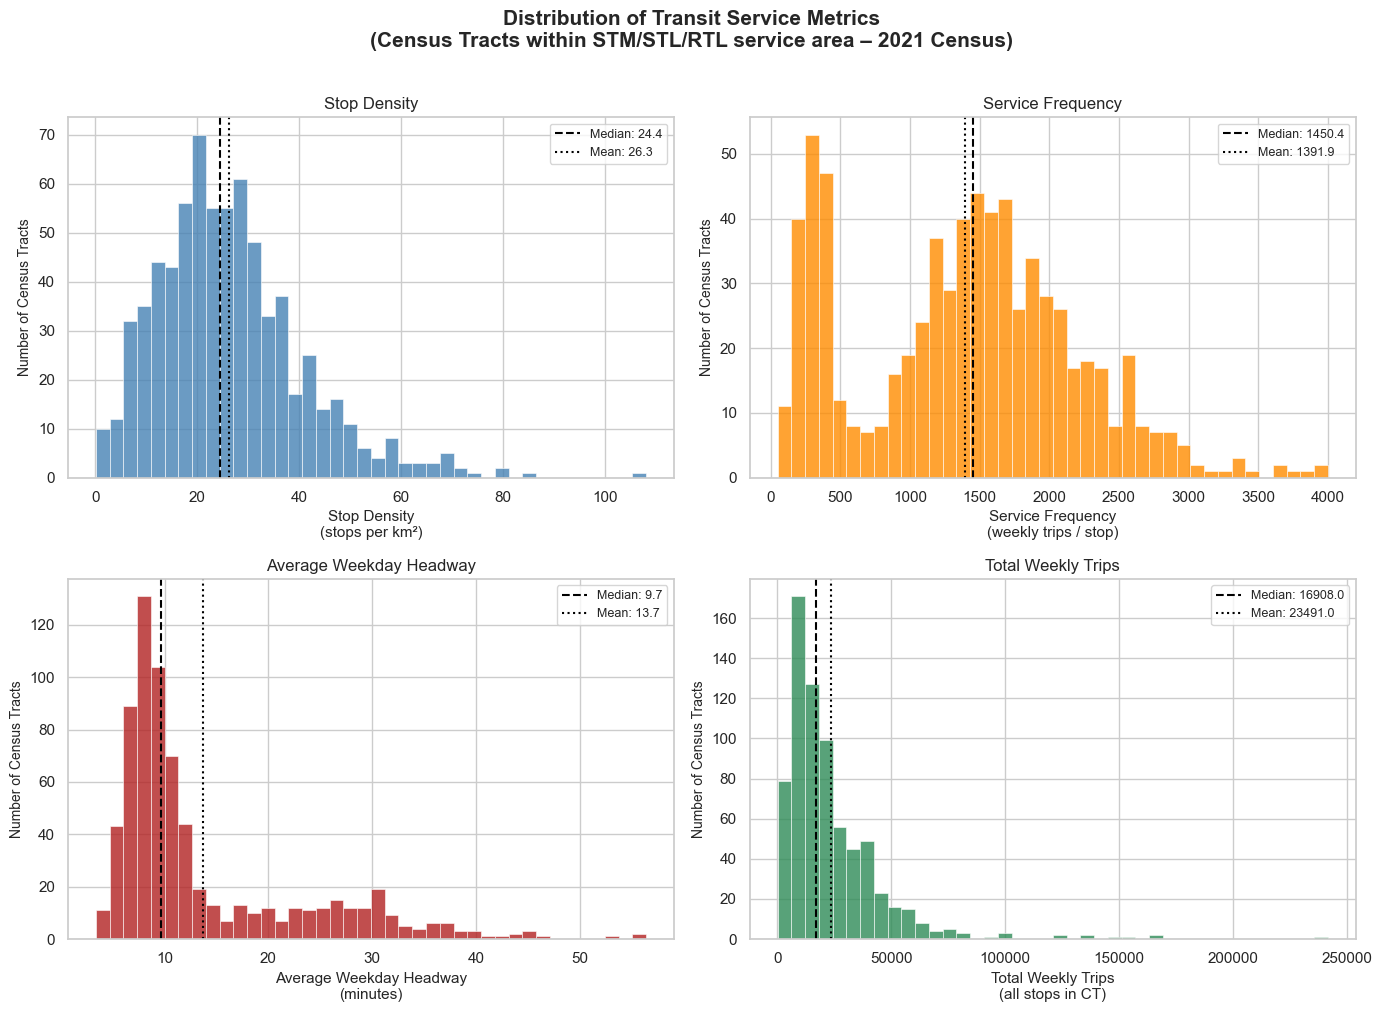

✅ Saved: figures/fig1_transit_distributions.png


In [144]:
# Distribution plots: transit service metrics (served CTs only) ─────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Transit Service Metrics\n'
             '(Census Tracts within STM/STL/RTL service area – 2021 Census)',
             fontsize=15, fontweight='bold', y=1.01)

plot_vars = [
    ('stop_density',      'Stop Density\n(stops per km²)',           'steelblue'),
    ('trips_per_stop',    'Service Frequency\n(weekly trips / stop)', 'darkorange'),
    ('avg_headway_min',   'Average Weekday Headway\n(minutes)',       'firebrick'),
    ('total_weekly_trips','Total Weekly Trips\n(all stops in CT)',    'seagreen'),
]

for ax, (col, label, color) in zip(axes.flat, plot_vars):
    data = master_served[col].dropna()

    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color='black', linestyle='--',
               linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.axvline(data.mean(),   color='black', linestyle=':',
               linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Number of Census Tracts', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_title(label.split('\n')[0], fontsize=12)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig1_transit_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig1_transit_distributions.png")

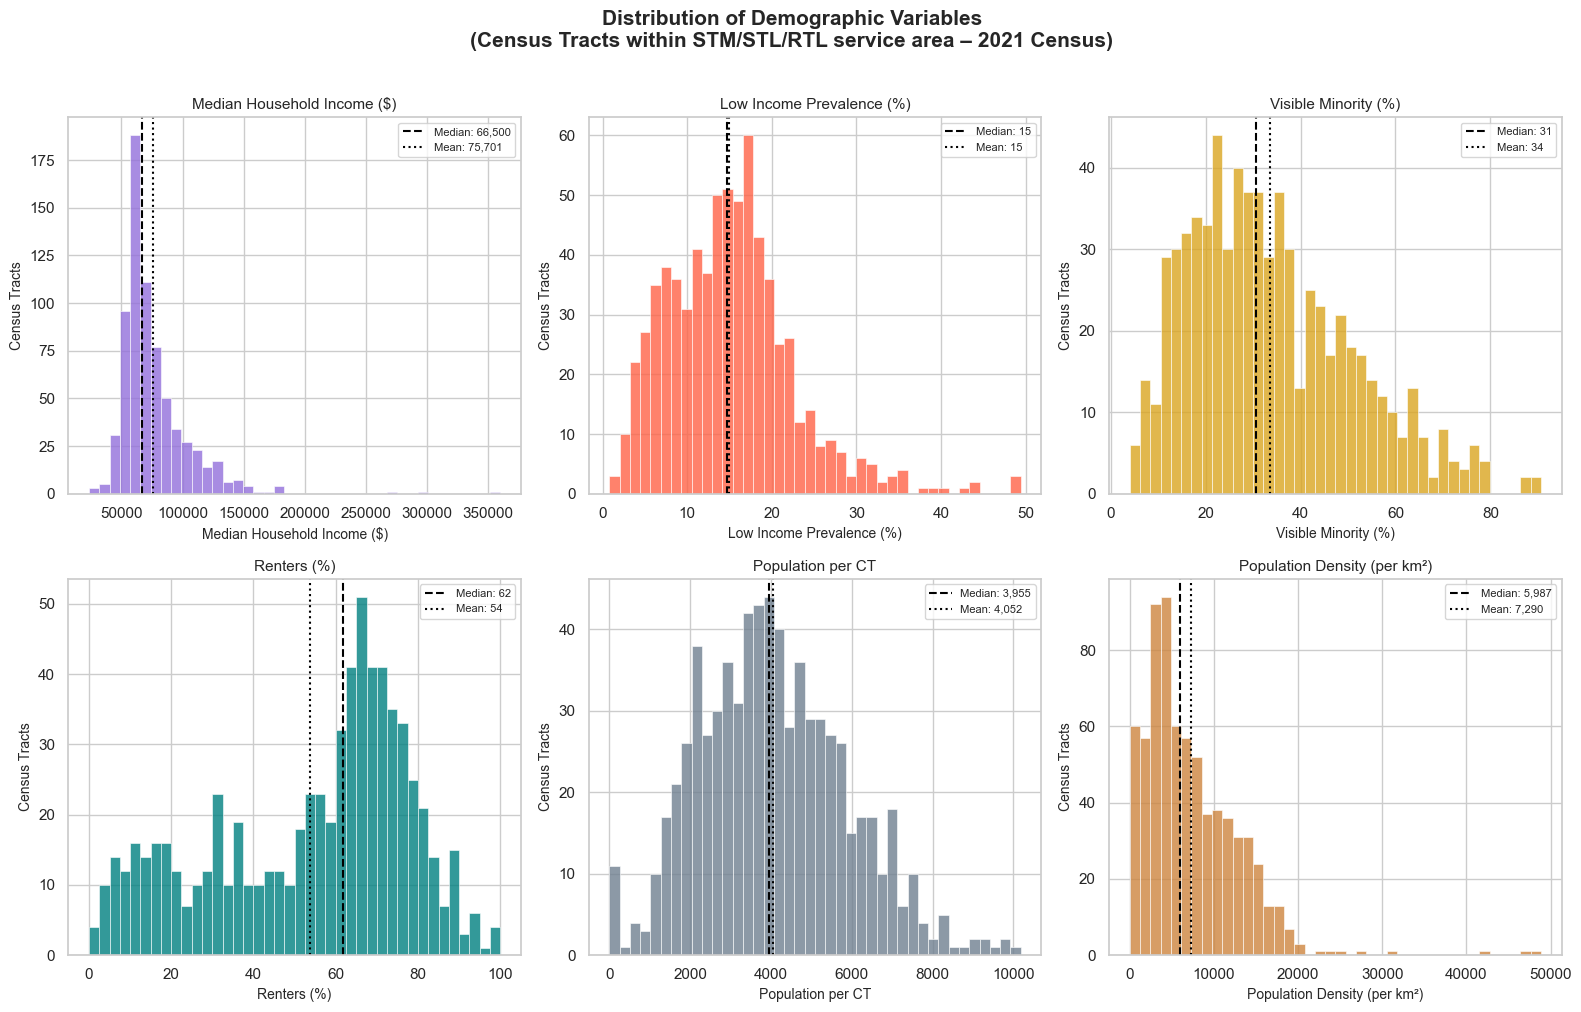

✅ Saved: figures/fig2_demographic_distributions.png


In [145]:
# Distribution plots: demographic variables (served CTs only) ───────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Demographic Variables\n'
             '(Census Tracts within STM/STL/RTL service area – 2021 Census)',
             fontsize=15, fontweight='bold', y=1.01)

demo_vars = [
    ('median_hh_income',     'Median Household Income ($)',  'mediumpurple'),
    ('pct_low_income',       'Low Income Prevalence (%)',     'tomato'),
    ('pct_visible_minority', 'Visible Minority (%)',          'goldenrod'),
    ('pct_renter',           'Renters (%)',                   'teal'),
    ('population',           'Population per CT',             'slategray'),
    ('pop_density',          'Population Density (per km²)',  'peru'),
]

for ax, (col, label, color) in zip(axes.flat, demo_vars):
    data = master_served[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color='black', linestyle='--',
               linewidth=1.5, label=f'Median: {data.median():,.0f}')
    ax.axvline(data.mean(),   color='black', linestyle=':',
               linewidth=1.5, label=f'Mean: {data.mean():,.0f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Census Tracts', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_title(label.split('\n')[0], fontsize=11)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig2_demographic_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig2_demographic_distributions.png")

### 5.3. Geographic Overview

The maps below provide an initial spatial view of the data. Patterns visible here motivate the formal analysis in Section 6.

Grey Census Tracts fall outside the STM/STL/RTL service footprint and are excluded from all comparisons, and only coloured CTs are part of the analysis.

**Figure 3: Stop Density *vs.* Median Household Income**
- **Left (Stop Density):** Transit infrastructure is heavily concentrated in the urban core of Montreal island, with coverage tapering toward the edges of the Laval and South Shore service areas.
- **Right (Median Household Income):** Lower-income CTs cluster in the same dense urban core, while higher-income CTs are predominantly found in the lower-density periphery of the service area.

Taken together, these 2 panels suggest that lower-income neighbourhoods may actually be better served. This pattern is driven by geography rather than deliberate policy, and examined formally in Section 6.

**Figure 4: Average Weekday Headway *vs.* Low-Income Prevalence**
- **Left (Average Headway):** Service frequency follows a clear core-periphery gradient: the shortest waits are in the urban core (green), lengthening toward the outer edges of all three service territories (red).
- **Right (Low-Income Prevalence):** High concentrations of low-income residents follow a similar geographic pattern, again concentrated toward the urban core.

The spatial alignment between these 2 panels (areas with longer headways tend to have lower low-income rates) reinforces the finding from Figure 3 and raises the central analytical question: is the apparent service advantage of lower-income CTs a deliberate equity outcome, or simply a consequence of where those CTs happen to be located?

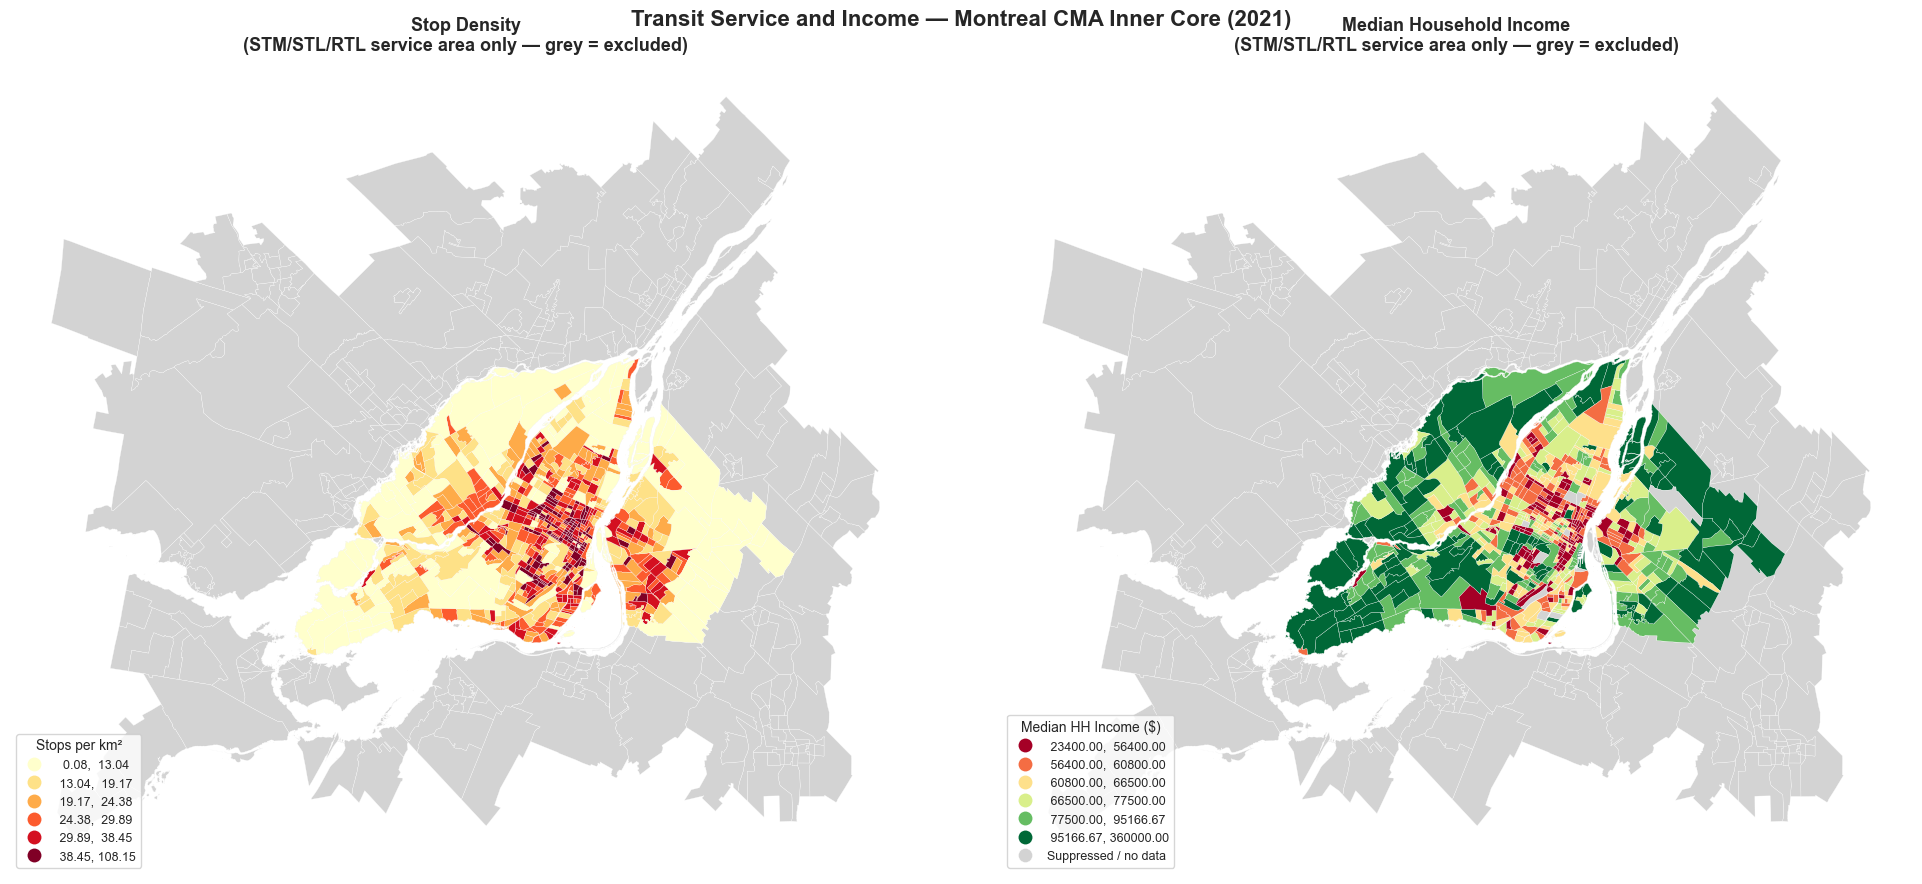

✅ Saved: figures/fig3_map_service_vs_income.png


In [146]:
# Choropleth maps: stop density and median household income ─────────────────

     # Both panels use master_served: stop density is undefined outside the service footprint, and we only compare household income where transit data exists.
     # Grey background shows the full CMA extent for geographic context.

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Transit Service and Income — Montreal CMA Inner Core (2021)',
             fontsize=16, fontweight='bold')

for ax in axes:
    master.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2)

# Left: stop density (served CTs only) ──────────────────────────────────────
master_served.plot(
    ax=axes[0],
    column='stop_density',
    cmap='YlOrRd',
    scheme='quantiles',
    k=6,
    legend=True,
    legend_kwds={
        'title': 'Stops per km²',
        'title_fontsize': 10,
        'fontsize': 9,
        'loc': 'lower left'
    },
    missing_kwds={'color': '#d3d3d3', 'label': 'No data'},
    edgecolor='white',
    linewidth=0.2
)
axes[0].set_title('Stop Density\n(STM/STL/RTL service area only — grey = excluded)',
                  fontsize=13, fontweight='bold')
axes[0].set_axis_off()

# Right: median household income (served CTs only) ─────────────────────────
master_served.plot(
    ax=axes[1],
    column='median_hh_income',
    cmap='RdYlGn',
    scheme='quantiles',
    k=6,
    legend=True,
    legend_kwds={
        'title': 'Median HH Income ($)',
        'title_fontsize': 10,
        'fontsize': 9,
        'loc': 'lower left'
    },
    missing_kwds={'color': '#d3d3d3', 'label': 'Suppressed / no data'},
    edgecolor='white',
    linewidth=0.2
)
axes[1].set_title('Median Household Income\n(STM/STL/RTL service area only — grey = excluded)',
                  fontsize=13, fontweight='bold')
axes[1].set_axis_off()

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig3_map_service_vs_income.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig3_map_service_vs_income.png")

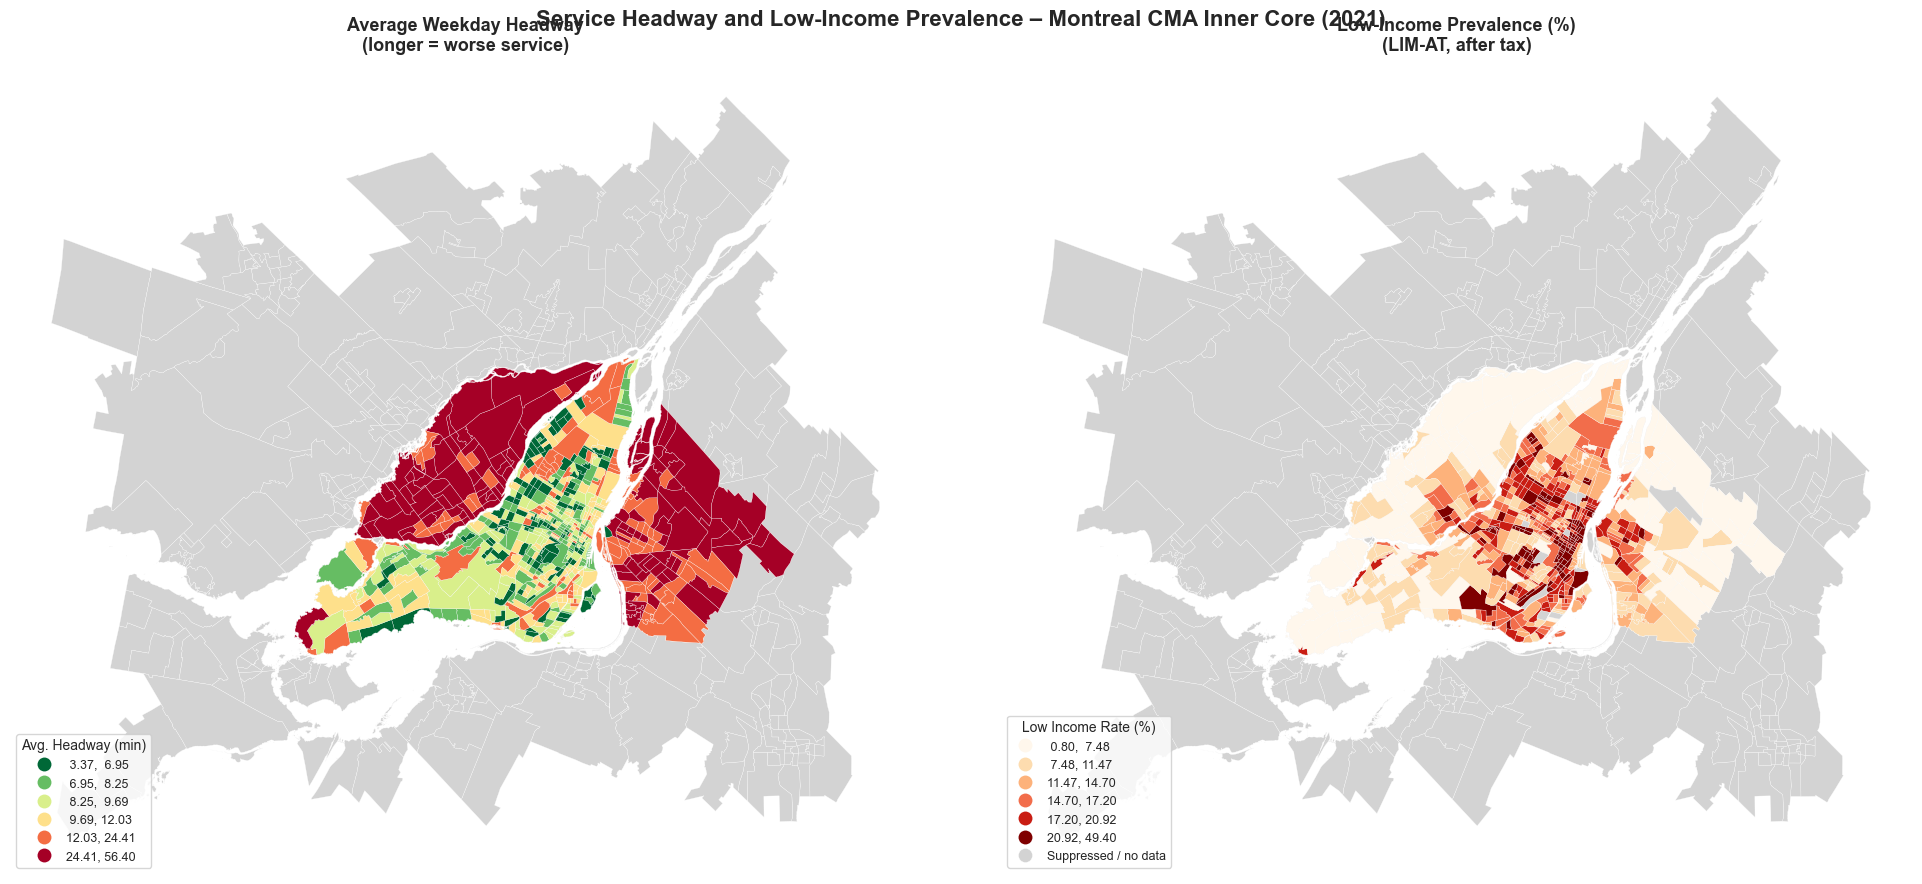

✅ Saved: figures/fig4_map_headway_vs_lowincome.png


In [147]:
# Choropleth maps: headway and low-income rate ──────────────────────────────

     # Both panels use master_served: headway is undefined outside the service footprint, and we only compare low-income rates where transit data exists.
     # Grey background shows the full CMA extent for geographic context.

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Service Headway and Low-Income Prevalence – Montreal CMA Inner Core (2021)',
             fontsize=16, fontweight='bold')

for ax in axes:
    master.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2)

# Left: average weekday headway (served CTs only) ───────────────────────────
master_served.plot(
    ax=axes[0],
    column='avg_headway_min',
    cmap='RdYlGn_r',
    scheme='quantiles',
    k=6,
    legend=True,
    legend_kwds={
        'title': 'Avg. Headway (min)',
        'title_fontsize': 10,
        'fontsize': 9,
        'loc': 'lower left'
    },
    missing_kwds={'color': '#d3d3d3', 'label': 'No data'},
    edgecolor='white',
    linewidth=0.2
)
axes[0].set_title('Average Weekday Headway\n(longer = worse service)',
                  fontsize=13, fontweight='bold')
axes[0].set_axis_off()

# Right: low-income prevalence (served CTs only) ────────────────────────────
master_served.plot(
    ax=axes[1],
    column='pct_low_income',
    cmap='OrRd',
    scheme='quantiles',
    k=6,
    legend=True,
    legend_kwds={
        'title': 'Low Income Rate (%)',
        'title_fontsize': 10,
        'fontsize': 9,
        'loc': 'lower left'
    },
    missing_kwds={'color': '#d3d3d3', 'label': 'Suppressed / no data'},
    edgecolor='white',
    linewidth=0.2
)
axes[1].set_title('Low-Income Prevalence (%)\n(LIM-AT, after tax)',
                  fontsize=13, fontweight='bold')
axes[1].set_axis_off()

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig4_map_headway_vs_lowincome.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig4_map_headway_vs_lowincome.png")

### 5.4. Transit Service by Income Quintile

We now ask a direct question: does transit service vary systematically across the income spectrum?

Census Tracts are divided into 5 equal-size groups (quintiles) by `median_hh_income`, across which we compare average transit service metrics. If transit is equitably distributed, bars should be roughly equal. If lower-income areas are underserved, bars should rise from Q1 to Q5.

Mean transit service metrics by income quintile:



,n_cts,median_income,mean_stop_density,mean_trips_per_stop,mean_headway,mean_pct_low_income
income_quintile,,,,,,
Q1\n(Lowest),141,52800.00,35.14,1823.29,10.12,25.07
Q2,153,60400.00,29.27,1522.54,12.10,17.43
Q3,128,67000.00,28.13,1526.62,11.53,15.12
Q4,139,80000.00,24.03,1129.24,15.81,10.66
Q5\n(Highest),141,110000.00,15.54,932.52,19.20,6.42


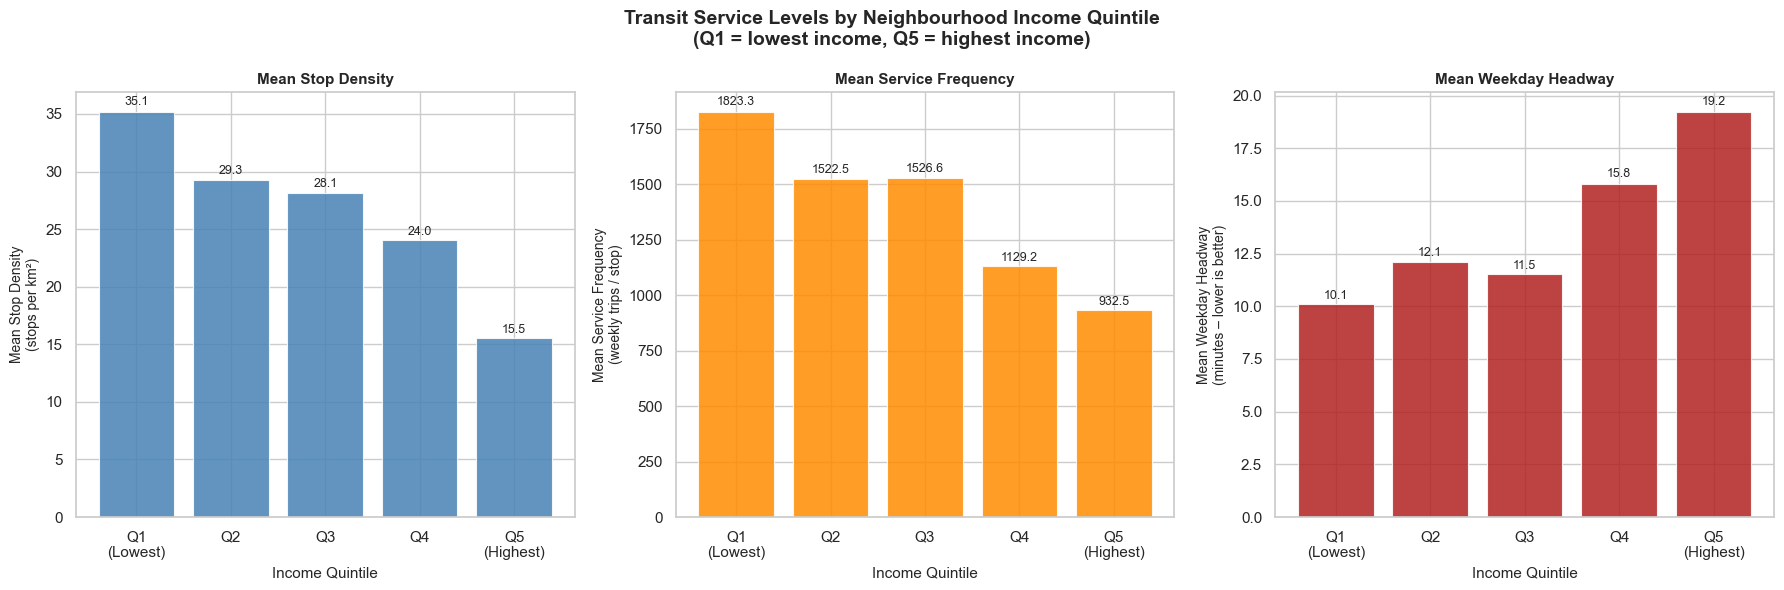

✅ Saved: figures/fig5_service_by_income_quintile.png


In [148]:
# Transit service by income quintile ────────────────────────────────────────

# Use master_served, already filtered to STM/STL/RTL service footprint.
master_q = master_served.dropna(subset=['median_hh_income', 'stop_density']).copy()

master_q['income_quintile'] = pd.qcut(
    master_q['median_hh_income'],
    q=5,
    labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)']
)

# Summary table ─────────────────────────────────────────────────────────────
quintile_summary = (
    master_q.groupby('income_quintile', observed=True)
    .agg(
        n_cts=('DGUID', 'count'),
        median_income=('median_hh_income', 'median'),
        mean_stop_density=('stop_density', 'mean'),
        mean_trips_per_stop=('trips_per_stop', 'mean'),
        mean_headway=('avg_headway_min', 'mean'),
        mean_pct_low_income=('pct_low_income', 'mean')
    )
    .round(2)
)

print("Mean transit service metrics by income quintile:\n")
display(quintile_summary)

# Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Transit Service Levels by Neighbourhood Income Quintile\n'
             '(Q1 = lowest income, Q5 = highest income)',
             fontsize=14, fontweight='bold')

metrics = [
    ('mean_stop_density',   'Mean Stop Density\n(stops per km²)',     'steelblue'),
    ('mean_trips_per_stop', 'Mean Service Frequency\n(weekly trips / stop)', 'darkorange'),
    ('mean_headway',        'Mean Weekday Headway\n(minutes – lower is better)', 'firebrick'),
]

for ax, (metric, ylabel, color) in zip(axes, metrics):
    bars = ax.bar(
        quintile_summary.index,
        quintile_summary[metric],
        color=color,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.8
    )
    # Value labels on top of each bar
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Income Quintile', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(ylabel.split('\n')[0], fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig5_service_by_income_quintile.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig5_service_by_income_quintile.png")

### 5.5. EDA Summary

The exploratory analysis of the STM/STL/RTL service area (n = 713 served Census Tracts) surfaces several clear and consistent patterns.

**Service distribution:**
- All transit service metrics are right-skewed: stop density ranges from 0.08 to 108 stops/km² with a median of 24.4; average weekday headway ranges from 3.4 to 56.4 minutes with a median of 9.7 minutes. A small number of central CTs drive the high end of both distributions.
- The median headway of **9.7 minutes** across the service area is a strong baseline: most riders within the STM/STL/RTL footprint have access to service better than a 10-minute wait.

**Income quintile pattern:**
The most striking finding from the EDA is a clear, monotonic relationship between neighbourhood income and transit service, running in the direction opposite to what an equity concern would predict:

| Quintile | Median Income | Stop Density (stops/km²) | Avg. Headway (min) |
|----------|--------------|--------------------------|-------------------|
| Q1 (Lowest)  | $52,800  | 35.1 | 10.1 |
| Q2           | $60,400  | 29.3 | 12.1 |
| Q3           | $67,000  | 28.1 | 11.5 |
| Q4           | $80,000  | 24.0 | 15.8 |
| Q5 (Highest) | $110,000 | 15.5 | 19.2 |

Lower-income Census Tracts have **2.3× higher stop density** and **47% shorter average headways** than the highest-income quintile. This is not evidence that agencies are targeting lower-income areas with better service, it is a geographic artifact. Lower-income CTs in the Montreal CMA are predominantly located in the dense urban core of Montreal island, where transit infrastructure has historically been concentrated. Higher-income CTs are disproportionately found in lower-density suburban areas of Laval and the South Shore, where per-km² stop coverage is inherently lower.

**This structural confound (income correlating with urban density) is the central methodological challenge of the regression in Section 6.**

**Geography:**
- The choropleth maps confirm a coherent, contiguous service area across the 3 agencies with no unexpected internal gaps.
- The headway map shows a clear core–periphery gradient within the service area: the inner Montreal island has the shortest headways (green), with headways lengthening toward the edges of the STL and RTL territories (red).
- This gradient largely mirrors the income map, motivating the formal test in Section 6.

---

## 6. Main Analysis

The EDA surfaced suggestive patterns between transit service and neighbourhood demographics. This section tests those patterns formally using:

1. **Spearman correlation matrix**: direction and strength of pairwise relationships
2. **Scatter plots with regression lines**: visual inspection of the key relationships
3. **OLS regression**: isolate the association between demographics and service, controlling for population density

All analyses use `master_served`. Variables with high skewness are log-transformed before regression to meet the linearity assumption. We use Spearman (rank) correlation throughout because several variables are non-normal.

> **Note on causation:**  
> This is an observational, cross-sectional study.
> Regression coefficients describe *associations*, not causal effects.
> Reverse causality is plausible in both directions (service shapes where > people live; where people live shapes where service runs).

### 6.1 Variable Preparation

Before modelling, we check skewness and apply log-transforms where needed. Right-skewed variables violate the normality-of-residuals assumption in OLS. A common threshold is |skewness| > 1 → log-transform.

In [149]:
# Skewness check and log-transformation ─────────────────────────────────────

model_vars = [
    'stop_density', 'avg_headway_min',           # dependent variables
    'median_hh_income', 'pct_low_income',        # SES predictors
    'pct_visible_minority', 'pct_renter',        # equity predictors
    'pop_density',                               # control
]

print("Skewness of raw variables (|skew| > 1 → log-transform):\n")
for v in model_vars:
    skew = master_served[v].dropna().skew()
    flag = '← log-transform' if abs(skew) > 1 else ''
    print(f"   {v:<30} skew = {skew:+.2f}  {flag}")

# Build regression DataFrame ─────────────────────────────────────────────────
     
# Drop rows missing any variable used in the models
reg_df = master_served[model_vars + ['DGUID']].dropna().copy()

# Log-transform skewed variables
     # We add a small epsilon to stop_density as a safety measure (all values should be > 0 in master_served, but protects against floating-point edge cases)
reg_df['log_stop_density']    = np.log(reg_df['stop_density']    + 1e-6)
reg_df['log_pop_density']     = np.log(reg_df['pop_density']     + 1e-6)
reg_df['log_median_hh_income']= np.log(reg_df['median_hh_income']+ 1e-6)

# avg_headway_min: check skewness output above, log-transform if |skew| > 1
headway_skew = master_served['avg_headway_min'].dropna().skew()
if abs(headway_skew) > 1:
    reg_df['log_avg_headway_min'] = np.log(reg_df['avg_headway_min'] + 1e-6)
    headway_col = 'log_avg_headway_min'
    print(f"\n→ avg_headway_min is log-transformed (skew = {headway_skew:.2f})")
else:
    headway_col = 'avg_headway_min'
    print(f"\n→ avg_headway_min used as-is (skew = {headway_skew:.2f})")

print(f"\n✅ Regression dataset: {len(reg_df):,} CTs "
      f"({len(master_served) - len(reg_df):,} dropped due to missing values)")

Skewness of raw variables (|skew| > 1 → log-transform):

   stop_density                   skew = +1.09  ← log-transform
   avg_headway_min                skew = +1.61  ← log-transform
   median_hh_income               skew = +3.26  ← log-transform
   pct_low_income                 skew = +1.00  
   pct_visible_minority           skew = +0.70  
   pct_renter                     skew = -0.55  
   pop_density                    skew = +1.95  ← log-transform

→ avg_headway_min is log-transformed (skew = 1.61)

✅ Regression dataset: 702 CTs (11 dropped due to missing values)


### 6.2 Spearman Correlation Matrix

Spearman rank correlation is used throughout because it is robust to non-normality and outliers, and because our key variables are not all normally distributed even after transformation. Values range from −1 (perfect negative association) to +1 (perfect positive association).

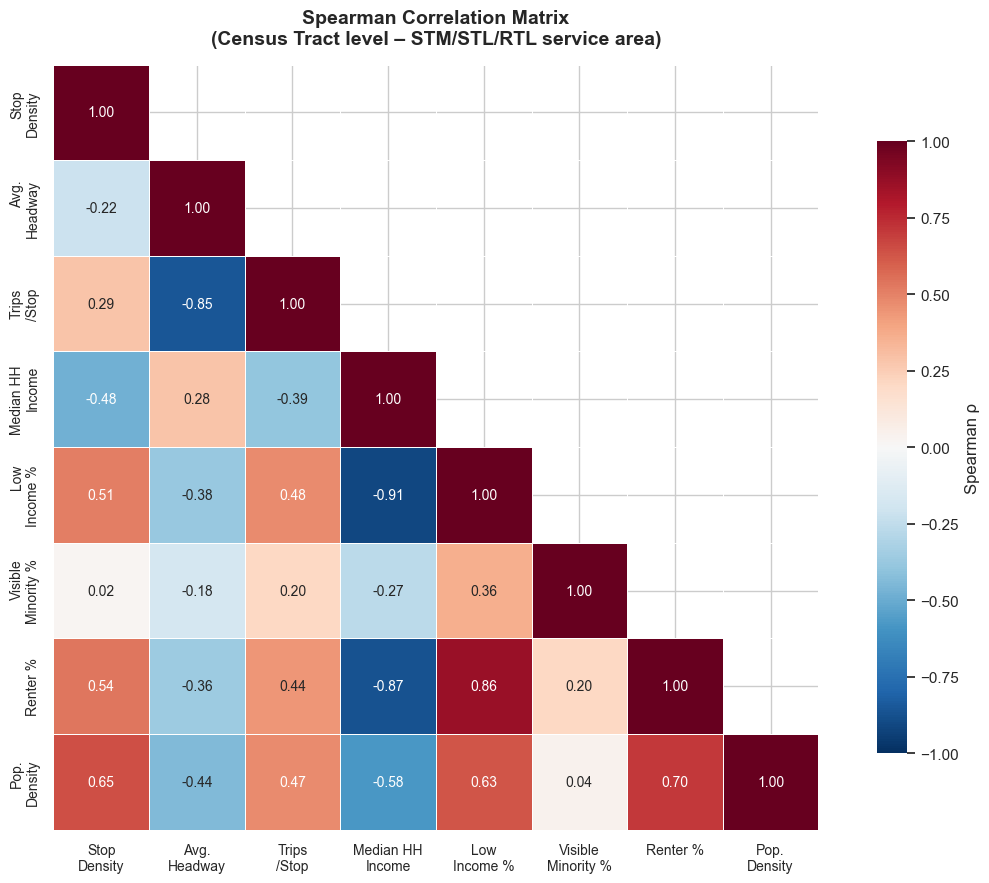

✅ Saved: figures/fig6_correlation_matrix.png


In [150]:
# Spearman correlation matrix ───────────────────────────────────────────────

corr_vars = {
    'stop_density'       : 'Stop\nDensity',
    'avg_headway_min'    : 'Avg.\nHeadway',
    'trips_per_stop'     : 'Trips\n/Stop',
    'median_hh_income'   : 'Median HH\nIncome',
    'pct_low_income'     : 'Low\nIncome %',
    'pct_visible_minority': 'Visible\nMinority %',
    'pct_renter'         : 'Renter %',
    'pop_density'        : 'Pop.\nDensity',
}

corr_data = master_served[list(corr_vars.keys())].dropna()
corr_matrix = corr_data.rename(columns=corr_vars).corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle mask

sns.heatmap(
    corr_matrix,
    ax=ax,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman ρ', 'shrink': 0.8},
    annot_kws={'size': 10}
)

ax.set_title('Spearman Correlation Matrix\n(Census Tract level – STM/STL/RTL service area)',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig6_correlation_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig6_correlation_matrix.png")

The matrix confirms a strong positive correlation between stop density and population density, and a clear negative correlation between income and headway, consistent with the income quintile patterns observed in Section 5.4. All relationships are tested formally in the regression below.

### 6.3 Scatter Plots

The scatter plots below show the six key relationships between transit service and demographic variables. Each panel includes a linear regression line (OLS on the raw, untransformed values for visual clarity) and the Spearman ρ from the correlation matrix above.

Two dependent variables are examined:
- **Stop density**: the *supply* dimension (*Is service physically accessible?*)
- **Average headway**: the *quality* dimension (*How long do riders wait?*)

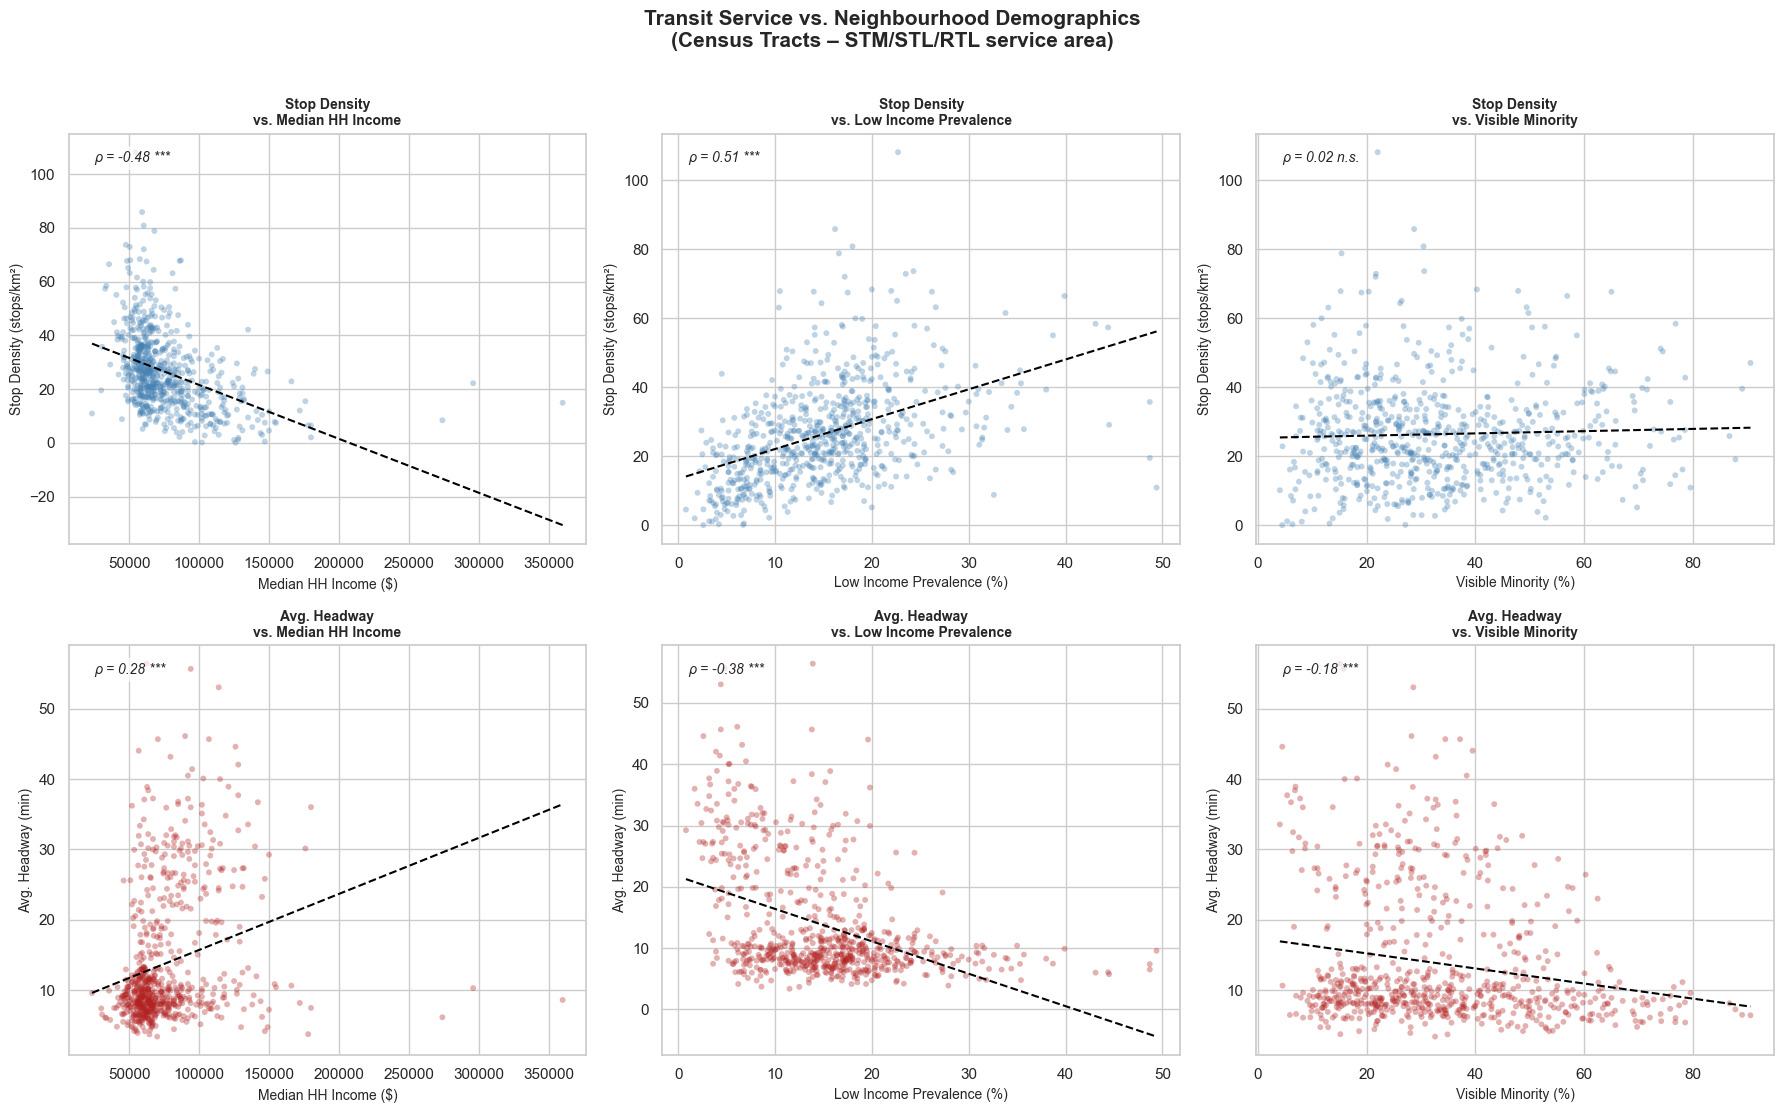

✅ Saved: figures/fig7_scatter_plots.png

*** p < 0.001   ** p < 0.01   * p < 0.05   n.s. not significant


In [151]:
# Scatter plots: transit service vs. demographics ───────────────────────────

scatter_df = master_served[
    ['stop_density', 'avg_headway_min',
     'median_hh_income', 'pct_low_income', 'pct_visible_minority']
].dropna()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Transit Service vs. Neighbourhood Demographics\n'
             '(Census Tracts – STM/STL/RTL service area)',
             fontsize=15, fontweight='bold', y=1.01)

pairs = [
    # (x_col,                  y_col,             x_label,                    y_label,                color)
    ('median_hh_income',   'stop_density',    'Median HH Income ($)',      'Stop Density (stops/km²)', 'steelblue'),
    ('pct_low_income',     'stop_density',    'Low Income Prevalence (%)', 'Stop Density (stops/km²)', 'steelblue'),
    ('pct_visible_minority','stop_density',   'Visible Minority (%)',      'Stop Density (stops/km²)', 'steelblue'),
    ('median_hh_income',   'avg_headway_min', 'Median HH Income ($)',      'Avg. Headway (min)',        'firebrick'),
    ('pct_low_income',     'avg_headway_min', 'Low Income Prevalence (%)', 'Avg. Headway (min)',        'firebrick'),
    ('pct_visible_minority','avg_headway_min','Visible Minority (%)',      'Avg. Headway (min)',        'firebrick'),
]

for ax, (x_col, y_col, x_label, y_label, color) in zip(axes.flat, pairs):
    x = scatter_df[x_col]
    y = scatter_df[y_col]

    ax.scatter(x, y, alpha=0.35, s=18, color=color, edgecolors='none')

    # OLS regression line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')

    # Spearman ρ annotation
    rho, pval = stats.spearmanr(x, y)
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    ax.annotate(f'ρ = {rho:.2f} {sig}',
                xy=(0.05, 0.93), xycoords='axes fraction',
                fontsize=10, fontstyle='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(f'{y_label.split("(")[0].strip()}\nvs. {x_label.split("(")[0].strip()}',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig7_scatter_plots.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig7_scatter_plots.png")
print("\n*** p < 0.001   ** p < 0.01   * p < 0.05   n.s. not significant")

### 6.4 OLS Regression

We fit two OLS models (one for each dependent variable) to isolate the association between neighbourhood demographics and transit service while controlling for population density.

**Model 1 – Stop Density (geographic coverage)**
$$\log(\text{stop density}) = \beta_0 + \beta_1 \log(\text{pop density}) + \beta_2 \log(\text{income}) + \beta_3 \text{low income\%} + \beta_4 \text{visible minority\%} + \beta_5 \text{renter\%} + \varepsilon$$

**Model 2 – Average Headway (service frequency)**
$$\text{headway} = \beta_0 + \beta_1 \log(\text{pop density}) + \beta_2 \log(\text{income}) + \beta_3 \text{low income\%} + \beta_4 \text{visible minority\%} + \beta_5 \text{renter\%} + \varepsilon$$

Population density is included as a control in both models. Denser areas mechanically require more stops to serve riders, so its coefficient is expected to be positive (Model 1) and negative (Model 2). The demographic coefficients tell us whether service is equitable *conditional on* density.

We check multicollinearity using the Variance Inflation Factor (VIF). Values above 5 indicate problematic collinearity.

In [152]:
# Multicollinearity check (VIF) ─────────────────────────────────────────────

from statsmodels.stats.outliers_influence import variance_inflation_factor

predictors = [
    'log_pop_density',
    'log_median_hh_income',
    'pct_low_income',
    'pct_visible_minority',
    'pct_renter',
]

vif_df = reg_df[predictors].dropna()
vif_data = pd.DataFrame({
    'Variable': predictors,
    'VIF': [variance_inflation_factor(vif_df.values, i)
            for i in range(len(predictors))]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factors:\n")
display(vif_data.round(2))
print("\nRule of thumb: VIF > 5 = moderate concern, VIF > 10 = serious concern.")
print("If log_median_hh_income and pct_low_income are both > 5, consider")
print("dropping pct_low_income (the weaker of the two) from the model.")

Variance Inflation Factors:



,Variable,VIF
0,log_pop_density,155.06
1,log_median_hh_income,105.17
4,pct_renter,23.56
2,pct_low_income,18.18
3,pct_visible_minority,6.24



Rule of thumb: VIF > 5 = moderate concern, VIF > 10 = serious concern.
If log_median_hh_income and pct_low_income are both > 5, consider
dropping pct_low_income (the weaker of the two) from the model.


#### Interpreting the VIF Results

The VIF values here are extreme: `log_pop_density` = 155, `log_median_hh_income` = 105, `pct_renter` = 23.6, `pct_low_income` = 18.2. These are far above the conventional
concern threshold of 10.

**Why this happens here:** All 5 predictors are, in different ways, proxies for the same underlying geographic dimension: *urban core vs. suburb*. Dense CTs tend to have lower incomes, higher renter rates, higher low-income rates, and higher visible minority proportions. In Montreal's inner CMA, these variables move together almost perfectly. They are not independent causes; they are correlated symptoms of a single structural gradient.

**What this means for interpretation:**
- The **overall model fit** (R², F-statistic) remains valid: collectively, the predictors explain real variance in service levels.
- **Individual coefficient estimates are unstable.** With VIFs this high, small changes in the data can flip signs or dramatically change magnitudes. Any individual coefficient should be treated as an unreliable estimate of a standalone effect.
- The **Spearman correlation matrix and income quintile analysis** (Section 5) provide more reliable variable-level insights than the regression coefficients in Model 1.
- **Model 2 (headway)** shows more stable behaviour in practice: its residuals are near-normally distributed and all predictors are strongly significant, suggesting the multicollinearity does not prevent the model from identifying real signal. Its coefficients should still be interpreted cautiously but directionally.

Given these constraints, we use the regression primarily to assess **collective explanatory power** and to confirm the direction of associations observed in the bivariate analysis, rather than to quantify precise marginal effects.

In [153]:
# OLS Model 1: Stop Density ─────────────────────────────────────────────────

model1_df = reg_df[
    ['log_stop_density', 'log_pop_density', 'log_median_hh_income',
     'pct_low_income', 'pct_visible_minority', 'pct_renter']
].dropna()

formula1 = ('log_stop_density ~ log_pop_density + log_median_hh_income '
            '+ pct_low_income + pct_visible_minority + pct_renter')

model1 = smf.ols(formula=formula1, data=model1_df).fit()

print("═" * 65)
print("  MODEL 1 – Dependent variable: log(Stop Density)")
print("═" * 65)
print(model1.summary())

═════════════════════════════════════════════════════════════════
  MODEL 1 – Dependent variable: log(Stop Density)
═════════════════════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:       log_stop_density   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     130.9
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.16e-97
Time:                        22:01:43   Log-Likelihood:                -524.78
No. Observations:                 702   AIC:                             1062.
Df Residuals:                     696   BIC:                             1089.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           c

In [154]:
# OLS Model 2: Average Headway ──────────────────────────────────────────────

model2_df = reg_df[
    [headway_col, 'log_pop_density', 'log_median_hh_income',
     'pct_low_income', 'pct_visible_minority', 'pct_renter']
].dropna()

formula2 = (f'{headway_col} ~ log_pop_density + log_median_hh_income '
            f'+ pct_low_income + pct_visible_minority + pct_renter')

model2 = smf.ols(formula=formula2, data=model2_df).fit()

print("═" * 65)
print(f"  MODEL 2 – Dependent variable: {headway_col}")
print("═" * 65)
print(model2.summary())

═════════════════════════════════════════════════════════════════
  MODEL 2 – Dependent variable: log_avg_headway_min
═════════════════════════════════════════════════════════════════
                             OLS Regression Results                            
Dep. Variable:     log_avg_headway_min   R-squared:                       0.328
Model:                             OLS   Adj. R-squared:                  0.323
Method:                  Least Squares   F-statistic:                     67.83
Date:                 Sun, 07 Jun 2026   Prob (F-statistic):           9.37e-58
Time:                         22:01:43   Log-Likelihood:                -466.97
No. Observations:                  702   AIC:                             945.9
Df Residuals:                      696   BIC:                             973.3
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                

### 6.5 Residual Diagnostics

Two standard checks for OLS assumptions:

1. **Residuals vs. Fitted**: should show no systematic pattern (linearity, homoscedasticity). A fan shape indicates heteroscedasticity.
2. **Q-Q plot**: residuals should follow the diagonal (normality). Deviations at the tails are common with spatial data and do not invalidate the model but widen confidence intervals.

Note that OLS assumes independent observations. Census Tracts are spatially contiguous, so residuals from neighbouring tracts are likely correlated (spatial autocorrelation). A full treatment would require spatial regression (e.g. spatial lag or spatial error model), which is beyond the scope of this analysis but is flagged as a natural extension in Section 9.

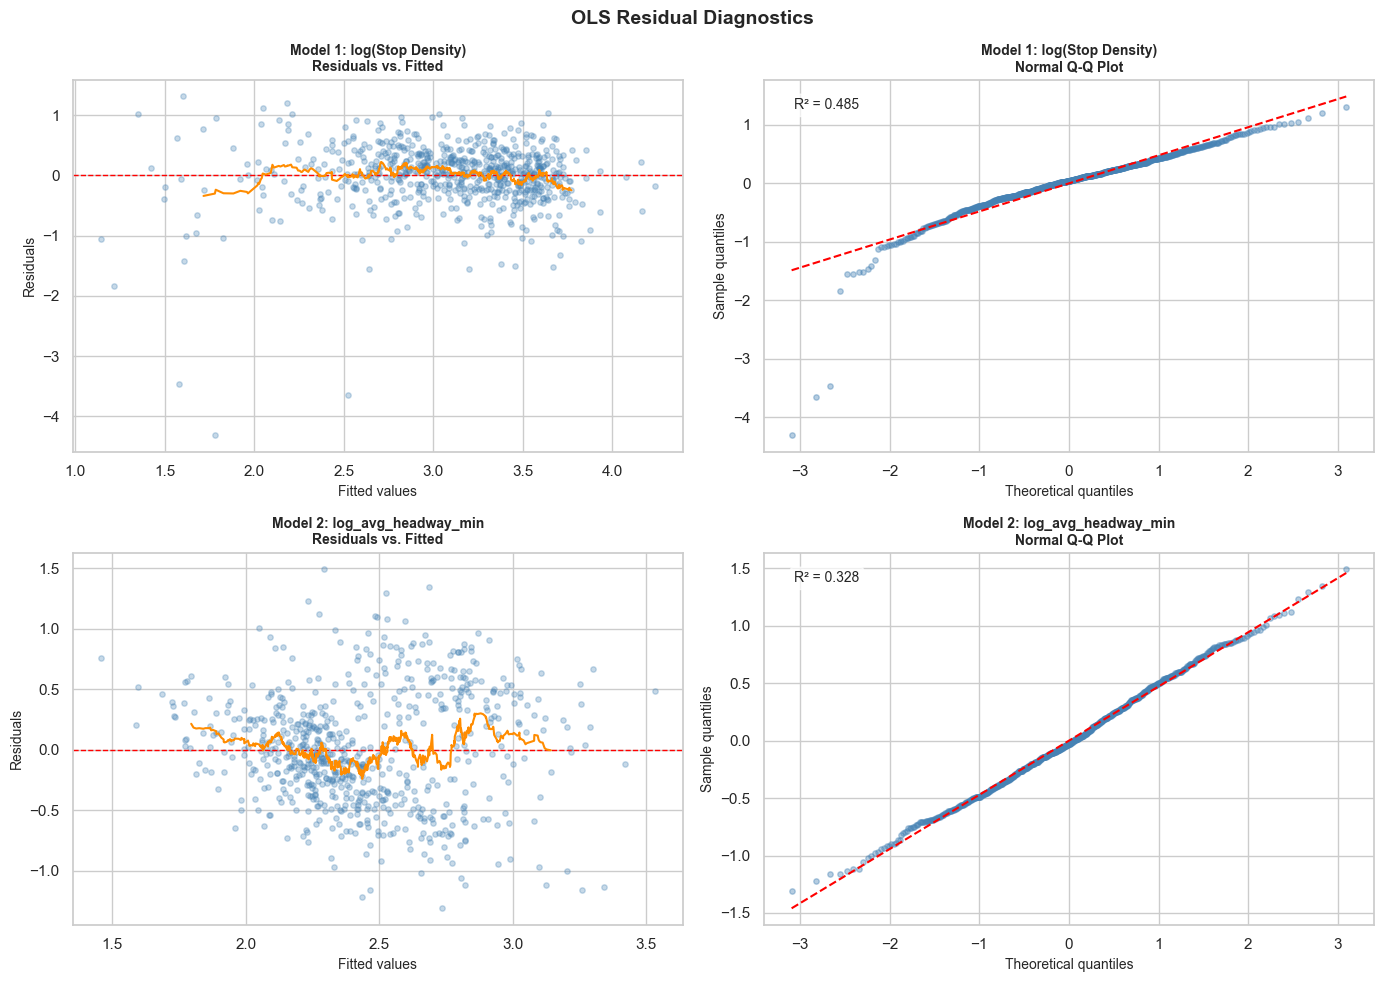

✅ Saved: figures/fig8_residual_diagnostics.png


In [155]:
# Residual diagnostics for both models ──────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('OLS Residual Diagnostics', fontsize=14, fontweight='bold')

for row, (model, name) in enumerate([(model1, 'Model 1: log(Stop Density)'),
                                      (model2, f'Model 2: {headway_col}')]):
    fitted   = model.fittedvalues
    residuals= model.resid

    # Residuals vs. Fitted ───────────────────────────────────────────────────
    axes[row, 0].scatter(fitted, residuals, alpha=0.3, s=15, color='steelblue')
    axes[row, 0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[row, 0].set_xlabel('Fitted values', fontsize=10)
    axes[row, 0].set_ylabel('Residuals', fontsize=10)
    axes[row, 0].set_title(f'{name}\nResiduals vs. Fitted', fontsize=10,
                            fontweight='bold')

    # Loess-style smoothed line using a rolling mean as approximation
    sorted_fitted = fitted.sort_values()
    sorted_resid  = residuals.loc[sorted_fitted.index]
    roll = pd.Series(sorted_resid.values).rolling(30, center=True).mean()
    axes[row, 0].plot(sorted_fitted.values, roll.values,
                      color='darkorange', linewidth=1.5)

    # Q-Q plot ───────────────────────────────────────────────────────────────
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
    axes[row, 1].scatter(osm, osr, alpha=0.4, s=15, color='steelblue')
    axes[row, 1].plot(osm, slope * np.array(osm) + intercept,
                      color='red', linestyle='--', linewidth=1.5)
    axes[row, 1].set_xlabel('Theoretical quantiles', fontsize=10)
    axes[row, 1].set_ylabel('Sample quantiles', fontsize=10)
    axes[row, 1].set_title(f'{name}\nNormal Q-Q Plot', fontsize=10,
                            fontweight='bold')

    # Annotate R²
    axes[row, 1].annotate(f"R² = {model.rsquared:.3f}",
                           xy=(0.05, 0.92), xycoords='axes fraction',
                           fontsize=10,
                           bbox=dict(boxstyle='round,pad=0.3',
                                     facecolor='white', alpha=0.7))

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig8_residual_diagnostics.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig8_residual_diagnostics.png")

In [156]:
# Side-by-side coefficient comparison ───────────────────────────────────────

     # This cell gives a clean visual summary of both models. It shows which predictors are statistically significant and in which direction.

def coef_table(model, name):
    tbl = pd.DataFrame({
        'Coefficient': model.params,
        'Std. Error' : model.bse,
        't-stat'     : model.tvalues,
        'p-value'    : model.pvalues,
    }).round(4)
    tbl['Significant'] = tbl['p-value'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01
                  else ('*' if p < 0.05 else ''))
    )
    tbl = tbl[tbl.index != 'Intercept']
    print(f"\n{'═'*60}")
    print(f"  {name}  |  R² = {model.rsquared:.3f}  |  n = {int(model.nobs)}")
    print(f"{'═'*60}")
    display(tbl)

coef_table(model1, 'Model 1 – log(Stop Density)')
coef_table(model2, f'Model 2 – {headway_col}')

print("\n*** p < 0.001   ** p < 0.01   * p < 0.05")


════════════════════════════════════════════════════════════
  Model 1 – log(Stop Density)  |  R² = 0.485  |  n = 702
════════════════════════════════════════════════════════════


,Coefficient,Std. Error,t-stat,p-value,Significant
log_pop_density,0.44,0.03,15.82,0.00,***
log_median_hh_income,-0.22,0.14,-1.59,0.11,
pct_low_income,-0.00,0.01,-0.37,0.71,
pct_visible_minority,-0.00,0.00,-0.78,0.43,
pct_renter,0.00,0.00,1.49,0.14,



════════════════════════════════════════════════════════════
  Model 2 – log_avg_headway_min  |  R² = 0.328  |  n = 702
════════════════════════════════════════════════════════════


,Coefficient,Std. Error,t-stat,p-value,Significant
log_pop_density,-0.18,0.03,-7.03,0.00,***
log_median_hh_income,-1.04,0.13,-8.06,0.00,***
pct_low_income,-0.02,0.01,-4.54,0.00,***
pct_visible_minority,-0.00,0.00,-2.85,0.00,**
pct_renter,-0.01,0.00,-6.61,0.00,***



*** p < 0.001   ** p < 0.01   * p < 0.05


### 6.6 Main Analysis Summary

**High multicollinearity caveat:**  
- As noted above, VIF values are extreme for all predictors. Individual coefficients, especially in Model 1, should not be interpreted as precise marginal effects. The bivariate Spearman correlations and income quintile comparisons remain the most reliable guides to variable-level relationships.

**Model fit:**  
- Model 1 (Stop Density) explains **48.5%** of variance in log stop density across the 702 Census Tracts in the regression dataset. Model 2 (log Headway) explains **32.8%**. Both models are highly significant overall (F-statistic p < 0.001).

**Population density (control):**  
- Population density is the only significant predictor in Model 1 (β = +0.44, p < 0.001): a 1% increase in population density is associated with a 0.44% increase in stop density, holding all else equal. This is expected: stops exist to serve concentrations of people, not as a response to demographic characteristics per se. The strong control effect of population density absorbs so much variance that no demographic variable reaches significance in Model 1.

In Model 2, population density is also highly significant (β = −0.18, p < 0.001): denser CTs have shorter headways, confirming that service frequency, not just stop coverage, is concentrated in the urban core.

**Demographic predictors – Model 1 (Stop Density):**  
- After controlling for population density, **none** of the demographic predictors reaches significance: median household income (β = −0.22, p = 0.11), low-income rate (p = 0.71), visible minority rate (p = 0.43), and renter rate (p = 0.14) are all statistically indistinguishable from zero.

**Interpretation:** Once we account for where people live (density), there is no detectable independent demographic signal in stop coverage. The geographic concentration of transit infrastructure in the urban core explains the apparent income gradient in stop density seen in the EDA, not deliberate targeting of any demographic group.

**Demographic predictors – Model 2 (Headway):**  
- In contrast to Model 1, all demographic predictors are significant in Model 2:

     | Predictor | β | p | Direction |
     |-----------|---|---|-----------|
     | log_pop_density | −0.18 | < 0.001 *** | Denser → shorter wait |
     | log_median_hh_income | −1.04 | < 0.001 *** | Higher income → shorter wait¹ |
     | pct_low_income | −0.023 | < 0.001 *** | More low-income → shorter wait¹ |
     | pct_visible_minority | −0.003 | 0.004 ** | More vis. minority → shorter wait¹ |
     | pct_renter | −0.011 | < 0.001 *** | More renters → shorter wait |

     ¹ *Coefficients are conditioned on all other variables including population density. Given the extreme multicollinearity (VIF > 100), directional interpretation should be treated with caution. The signs are consistent with urban core CTs outperforming suburban CTs on all dimensions simultaneously.*

     The Durbin-Watson statistic for Model 2 is **0.882** (well below the ideal of 2.0), confirming positive spatial autocorrelation in the residuals. Neighbouring CTs are more similar to each other than the model predicts, a natural property of geographic data and a formal argument for spatial regression as a next step (Section 9).

**Core takeaway:**
- Transit service within the STM/STL/RTL area is primarily structured by geography, not demographics. The urban core receives concentrated service because it is dense, not because agencies are directing resources toward lower-income or minority populations. Conversely, higher-income suburban CTs have lower service density and longer waits not because of demographic bias against them, but because suburban geographies are structurally difficult to serve efficiently by transit. **The equity question this analysis cannot yet answer is whether the *suburban residents who are lower-income* are adequately served, a question that requires finer geographic resolution than Census Tract aggregates can provide.**

---

## 7. Key Findings

This analysis examined transit equity across **713 Census Tracts** within the combined STM, STL and RTL service area, using GTFS schedule data from June 2026 and 2021 Census demographics.

>### Finding 1: Population density, not demographics, drives stop coverage

Stop density is overwhelmingly explained by population density (β = +0.44, p < 0.001, R² = 0.485). Once density is controlled for, no demographic variable (income, low-income rate, visible minority share, renter rate) is a statistically significant predictor of how many stops a neighbourhood has.

Transit infrastructure in Montreal's inner CMA follows people, not demographics. This is broadly equitable in the sense that no group is systematically excluded from physical access to transit. It also means the apparent advantage of lower-income CTs in raw stop counts is a geographic artifact, not a policy outcome.

>### Finding 2: Lower-income CTs have better service, but for geographic reasons

Across income quintiles, stop density falls monotonically from the lowest-income quintile (35.1 stops/km²) to the highest (15.5 stops/km²), and average headway rises from 10.1 to 19.2 minutes. Lower-income residents within the service area are, on average, better served by transit than higher-income residents.

**However, this reflects the geography of Montreal's income distribution rather than equity-driven planning.** Lower-income CTs cluster in the dense urban core of Montreal island (where transit has been built up over decades), while higher-income CTs are concentrated in the lower-density suburbs of Laval and the South Shore. Riders in wealthier suburbs face longer waits not because agencies have prioritised services elsewhere, but because low-density geography makes frequent service operationally expensive per rider.

>### Finding 3: Service frequency shows a significant but complex demographic signal

Model 2 explains 32.8% of variance in average headway, with all 5 predictors statistically significant. Controlling for population density, CTs with higher visible minority shares (β = −0.003, p = 0.004) and higher renter rates (β = −0.011, p < 0.001) have modestly shorter headways. These associations are consistent in direction with the bivariate Spearman correlations and the income quintile table.

The extreme multicollinearity among predictors (VIF > 100 for key variables) makes precise coefficient interpretation unreliable. The robust conclusions are: (a) demographics collectively explain meaningful variance in service frequency, and (b) the direction of all associations is consistent with urban-core CTs outperforming suburban CTs on all dimensions simultaneously. Disentangling the independent contribution of each demographic factor would require either a spatial regression model or a study design with more geographic variation.

>### Finding 4: The real equity risk is in the gap between these findings and rider experience

The scheduled GTFS data analysed here presents a relatively benign picture: lower-income CTs have more stops and shorter scheduled headways. But scheduled service is not experienced service. Real-time reliability data (the kind that only transit apps like Transit routinely collect) would be needed to test whether service disruptions, cancellations, and overcrowding fall disproportionately on lower-income neighbourhoods, potentially erasing the paper advantage they appear to have.

### Summary

| Dimension | Pattern observed | Equity concern? |
|-----------|-----------------|-----------------|
| Stop density (supply) | Higher in lower-income CTs | Low (driven by density, not demographics) |
| Headway (frequency) | Shorter in lower-income CTs | Low at aggregate level; suburban gaps warrant monitoring |
| Visible minority % | Weakly associated with shorter headway | No evidence of systematic disadvantage |
| Renter % | Associated with shorter headway | Renters (transit-dependent) tend to live in well-served areas |
| Reliability (actual service) | Not measured in this analysis | **Unknown (highest priority for future work)** |

---

## 8. Recommendations

The following recommendations are addressed to transit agency planning departments and draw directly from the findings above. They are ordered by feasibility, from actions that require only data and policy commitment to those that require capital investment.

>### 1. Adopt headway as the primary equity metric in service planning

Stop density is a necessary but insufficient measure of transit access. Two neighbourhoods can have the same number of stops with radically different service frequencies. Since headway is what determines how long a rider actually waits, it is the more meaningful equity metric and should be tracked explicitly as part of service equity reporting.

**Action:** Incorporate minimum frequency standards (e.g. 15-minute maximum headway during peak hours) as an explicit criterion in service allocation decisions, with a geographic equity lens applied at the Census Tract level.

>### 2. Conduct regular equity audits using open GTFS and Census data

The methodology used in this analysis is entirely reproducible using publicly available data and open-source tools. There is no reason for this to be a one-time exercise.

**Action:** Establish an annual equity audit cycle: update the GTFS feed at the start of each service period, re-run the spatial join and regression, and flag CTs whose service levels fall below the regional median by more than one standard deviation. Publish results transparently.

>### 3. Monitor service frequency in lower-density suburban CTs, particularly those with lower incomes

The income quintile analysis shows that the highest-income CTs have average headways nearly twice as long as the lowest-income quintile (19.2 vs. 10.1 minutes). Most of this gap is geographic: high-income CTs are concentrated in lower-density suburbs where intensive service is operationally expensive.

However, this aggregate picture may hide pockets of suburban lower-income CTs that face both low service frequency and limited financial means to supplement it with car ownership. These CTs sit at the intersection of geographic disadvantage and socioeconomic vulnerability.

**Action:** Map CTs in the lowest 2 income quintiles that also have average headways above 20 minutes. Flag these as high-priority candidates for service frequency review in the next network planning cycle, particularly in the RTL and STL service areas where suburban geography is most pronounced.

>### 4. Invest in reliability data to complement scheduled-service analysis

This analysis shows that scheduled service, measured via GTFS, is reasonably equitable across the STM/STL/RTL inner CMA. But scheduled service is not the same as experienced service. A bus route with a 10-minute scheduled headway that routinely runs late, bunches, or is cancelled delivers far less value to its riders than the timetable suggests.

Transit apps that collect real-time position and arrival data, including Transit, are uniquely positioned to measure *actual* service delivery at the stop and route level. This data, cross-referenced with neighbourhood demographics, would answer a question this analysis cannot: whether service reliability gaps compound or counteract the supply patterns identified here.

**Action:** Partner with a real-time data provider to conduct a reliability audit for the STM/STL/RTL network. Measure on-time performance, bunching frequency, and effective headway by CT, then re-run the demographic correlations on actual rather than scheduled service.

>### 5. Extend this analysis to include the full Montreal CMA

This study intentionally limits its scope to the STM, STL and RTL service areas. Exo's outer-suburb network and commuter rail system represent the next layer of complexity, including the equity implications of park-and-ride-oriented service that may systemically favour car-owning suburban populations.

**Action:** Extend the GTFS harmonization effort to include all exo sectors and the REM, and run a comparable equity analysis across the full CMA.

---

## 9. Limitations and Next Steps

>### Methodological limitations

**Scheduled vs. actual service.**  
- GTFS static feeds represent the *published timetable*, not actual vehicle movements. Buses that run late or are cancelled are not captured here. Real-time or historical AVL (Automatic Vehicle Location) data would give a more accurate picture of the service riders actually experience. Transit apps like Transit are uniquely positioned to provide this data.

**Spatial autocorrelation.**  
- OLS regression assumes independent observations. Census Tracts are spatially contiguous and neighbouring tracts share many characteristics, meaning residuals are likely spatially correlated. A spatial lag or spatial error model (implemented via the `pysal` library) would address this and may shift coefficient estimates. This is the most important methodological extension for future work.

**Stop-level vs. route-level analysis.**  
- This analysis aggregates all stops within a CT and treats them as equivalent. In reality, a metro station and a single-route bus stop differ enormously in the service they provide. A route-level or mode-level decomposition would capture this nuance.

**Census data vintage.**  
- Demographic data is from the 2021 Census. Service data is from June 2026. A five-year gap means some CTs will have changed demographically (particularly in rapidly gentrifying or growing areas), while service levels have remained constant. This is a structural limitation of combining census and GTFS data and affects all similar studies.

**Scope exclusions.**  
- exo's regional bus network and commuter rail, and the REM, are not included. Some Census Tracts at the edge of the STL and RTL service areas receive partial coverage from exo routes that cross into their territory. These are treated as served by STL/RTL only, which may undercount service in boundary areas.

>### Next steps

1. **Spatial regression**: Apply a spatial lag model to account for geographic autocorrelation and re-test the demographic coefficients.

2. **Mode decomposition**: Separate metro, BRT and local bus service within the STM feed to test whether mode of service varies systematically by neighbourhood income.

3. **Temporal analysis**: Repeat the analysis using GTFS snapshots from prior years to detect whether equity gaps have widened or narrowed over time, particularly following the COVID-19 service cuts of 2020–21.

4. **Full CMA extension**: Integrate all exo bus sectors and REM GTFS data to produce a complete Montreal CMA equity analysis.

5. **Ridership validation**: Cross-reference service metrics with actual ridership data (where available through agency partnerships) to assess whether supply-side metrics predict demand-side outcomes.